In [ ]:
#mount gdrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<a id="imported-libraries"></a>
## <font style = 'color:black'>001 - Imported libraries</font>


In [ ]:
# Import all relevant libraries
import pandas as pd # Tables
import numpy as np # math calculation
import matplotlib.pyplot as plt # Visualisation
import matplotlib.dates as mdates # Visualisation
import seaborn as sns # Visualisation

# Additional libraries
from pathlib import Path # For getting filename in OS
from scipy.stats import skew # For Linear Regression to be symmetric
from sklearn.preprocessing import StandardScaler # For Linear Regression for standardizing features
import scipy.stats as stats # Functions for computing correlation coefficients
import joblib # To save predictive model data into joblib file to load on Streamlit

# Feature Importance & Predictive Model Libraries
from matplotlib.ticker import PercentFormatter # Convert format axis tick labels as percentages
from sklearn.model_selection import train_test_split # training 80%, testing 20%
from sklearn.linear_model import LinearRegression, Ridge # Model 2, Model 3
from sklearn.ensemble import RandomForestRegressor # Model 4
from sklearn.dummy import DummyRegressor # Model 1
from sklearn.preprocessing import LabelEncoder # Encode categorical to numeric
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import BallTree

# Libraries for API calls
import requests
import json
from tqdm import tqdm #create a progress bar for an iterable, typically a loop
import time #provides various time-related functions

# This makes the picture stay on the page! Not open a new one
%matplotlib inline

<a id="data-cleaning"></a>
## <font style = 'color:black'>002 - Load CSV & Data Cleaning</font>
---
We clean the data by handling nulls, duplicates and fixing data types.

1. Load CSV that is derived from [HDB resale flat Geodata API](https://colab.research.google.com/drive/10LrMEK-xo7Kryi0biph4JhHLKX9u5MZr#scrollTo=44f3752d)
2. Rename the columns
3. Check for null values
4. Check for duplicate values
5. Check for NIL values in postal code
6. Save the cleaned CSV files


In [ ]:
hdb_price = pd.read_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_final_with_cpi.csv')
hdb_price.head()

/tmp/ipykernel_5866/2402809111.py:1: DtypeWarning: Columns (9,12) have mixed types. Specify dtype option on import or set low_memory=False.
  hdb_price = pd.read_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_final_with_cpi.csv')


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,priority_school_dist_km,num_priority_sch_1km,num_priority_sch_2km,Nearest MRT Station,MRT_dist_km,num_mrt_1km,Nearest MRT interchange,MRT_interchange_dist_km,num_mrt_interchange_1km,cpi
0,2015-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,07 TO 09,60.0,Improved,1986,70,...,0.415275,1.0,2.0,Mayflower,0.420669,1.0,Bishan,3.013362,0.0,85.179
1,2015-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1981,65,...,2.132093,0.0,0.0,Ang Mo Kio,0.806901,1.0,Bishan,2.620788,0.0,85.179
2,2015-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,01 TO 03,69.0,New Generation,1980,64,...,0.436188,1.0,2.0,Mayflower,0.292828,1.0,Bishan,2.831995,0.0,85.179
3,2015-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1979,63,...,1.875405,0.0,1.0,Ang Mo Kio,0.688394,1.0,Bishan,1.952634,0.0,85.179
4,2015-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,64,...,1.898682,0.0,1.0,Ang Mo Kio,0.928377,1.0,Bishan,2.445208,0.0,85.179


In [ ]:
# Check the columns and rows, missing value, data types
print(f'hdb_price.csv shape: {hdb_price.shape}')
print(f'hdb_price.csv nulls:', hdb_price.isnull().sum().sum())
print(f'hdb_price.csv data types:\n{hdb_price.dtypes}\n')

hdb_price.csv shape: (260568, 38)
hdb_price.csv nulls: 5350
hdb_price.csv data types:
month                       object
town                        object
flat_type                   object
block                       object
street_name                 object
storey_range                object
floor_area_sqm             float64
flat_model                  object
lease_commence_date          int64
remaining_lease             object
resale_price               float64
address                     object
postal_code                 object
latitude                   float64
longitude                  float64
bus_stop_dist              float64
num_bus_stop_1km           float64
hawker_dist                float64
num_hawker_1km             float64
park_dist                  float64
num_park_1km               float64
mall_dist                  float64
num_mall_1km               float64
Nearest school              object
school_dist                float64
num_school_1km             float64
num_

In [ ]:
hdb_price.dropna(subset=['latitude', 'longitude'], inplace=True)

# Check the columns and rows, missing value, data types
print(f'hdb_price.csv shape: {hdb_price.shape}')
print(f'hdb_price.csv nulls:', hdb_price.isnull().sum().sum())
print(f'hdb_price.csv data types:\n{hdb_price.dtypes}\n')

hdb_price.csv shape: (260354, 38)
hdb_price.csv nulls: 0
hdb_price.csv data types:
month                       object
town                        object
flat_type                   object
block                       object
street_name                 object
storey_range                object
floor_area_sqm             float64
flat_model                  object
lease_commence_date          int64
remaining_lease             object
resale_price               float64
address                     object
postal_code                 object
latitude                   float64
longitude                  float64
bus_stop_dist              float64
num_bus_stop_1km           float64
hawker_dist                float64
num_hawker_1km             float64
park_dist                  float64
num_park_1km               float64
mall_dist                  float64
num_mall_1km               float64
Nearest school              object
school_dist                float64
num_school_1km             float64
num_sch

In [ ]:
# 1. List the distance columns to convert
# features: bus_stop_dist, hawker_dist, park_dist, mall_dist,
# MRT_interchange_dist_km, priority_school_dist_km, MRT_dist_km, school_dist
dist_cols_km = [
    'bus_stop_dist', 'hawker_dist', 'park_dist', 'mall_dist',
    'MRT_interchange_dist_km', 'priority_school_dist_km',
    'MRT_dist_km', 'school_dist'
]

# 2. Convert to meters and round to nearest whole number
for col in dist_cols_km:
    # Create a new name (e.g., 'bus_stop_dist_m')
    new_name = col.replace('_km', '') + '_m'
    hdb_price[new_name] = round(hdb_price[col] * 1000, 2)

# 3. Optional: Drop the old KM columns to keep the data clean
hdb_price = hdb_price.drop(columns=dist_cols_km)

# 4. Verify
print("Distances converted to Meters:")
display(hdb_price.filter(like='_m').head())

Distances converted to Meters:


,flat_model,num_mall_1km,num_mrt_1km,num_mrt_interchange_1km,bus_stop_dist_m,hawker_dist_m,park_dist_m,mall_dist_m,MRT_interchange_dist_m,priority_school_dist_m,MRT_dist_m,school_dist_m
0,Improved,1.0,1.0,0.0,96.07,184.32,338.00,990.47,3013.36,415.28,420.67,415.28
1,New Generation,2.0,1.0,0.0,93.48,181.90,700.46,897.30,2620.79,2132.09,806.90,454.51
2,New Generation,1.0,1.0,0.0,97.76,155.57,175.61,882.45,2832.00,436.19,292.83,436.19
3,New Generation,2.0,1.0,0.0,171.10,124.09,633.87,784.06,1952.63,1875.40,688.39,368.97
4,New Generation,0.0,1.0,0.0,111.88,386.06,834.99,1063.88,2445.21,1898.68,928.38,665.00


In [ ]:
# Convert month & year integers to datetime
hdb_price['sale_date'] = pd.to_datetime(hdb_price['month'], format='%Y-%m')

# Create the 'year' column by extracting the year from the datetime object
hdb_price['year'] = hdb_price['sale_date'].dt.year
hdb_price['month'] = hdb_price['sale_date'].dt.month
hdb_price['lease_commence_date'] = pd.to_datetime(hdb_price['lease_commence_date'], format='%Y')

# Get a list of all current columns
cols = list(hdb_price.columns)

# Remove 'year' from wherever it currently is (usually at the very end)
cols.remove('year')
cols.remove('sale_date')

# Find the position of 'month' and insert 'year' & 'sale_date' immediately after it
month_index = cols.index('month')
cols.insert(month_index + 1, 'year')
cols.insert(month_index + 2, 'sale_date')


# Reorder the DataFrame using the newly arranged column list
hdb_price = hdb_price[cols]


# Check the columns and rows
print(f'hdb_price shape: {hdb_price.shape}')
print(hdb_price.head())
print(f'hdb_price data types:\n{hdb_price.dtypes}\n')


hdb_price shape: (260354, 40)
   month  year  sale_date        town flat_type block        street_name  \
0      1  2015 2015-01-01  ANG MO KIO    3 ROOM   174   ANG MO KIO AVE 4   
1      1  2015 2015-01-01  ANG MO KIO    3 ROOM   541  ANG MO KIO AVE 10   
2      1  2015 2015-01-01  ANG MO KIO    3 ROOM   163   ANG MO KIO AVE 4   
3      1  2015 2015-01-01  ANG MO KIO    3 ROOM   446  ANG MO KIO AVE 10   
4      1  2015 2015-01-01  ANG MO KIO    3 ROOM   557  ANG MO KIO AVE 10   

  storey_range  floor_area_sqm      flat_model  ... num_mrt_interchange_1km  \
0     07 TO 09            60.0        Improved  ...                     0.0   
1     01 TO 03            68.0  New Generation  ...                     0.0   
2     01 TO 03            69.0  New Generation  ...                     0.0   
3     01 TO 03            68.0  New Generation  ...                     0.0   
4     07 TO 09            68.0  New Generation  ...                     0.0   

      cpi  bus_stop_dist_m hawker_dist

In [ ]:
#get hdb age
hdb_price['hdb_age'] = hdb_price['year'] - hdb_price['lease_commence_date'].dt.year
# Splits storey range to mid "04 TO 06" -> 5.0
temp_split = hdb_price['storey_range'].str.split(' TO ', expand=True).astype(int)
hdb_price['mid'] = (temp_split[0] + temp_split[1]) / 2

hdb_price.head()

,month,year,sale_date,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,...,bus_stop_dist_m,hawker_dist_m,park_dist_m,mall_dist_m,MRT_interchange_dist_m,priority_school_dist_m,MRT_dist_m,school_dist_m,hdb_age,mid
0,1,2015,2015-01-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,07 TO 09,60.0,Improved,...,96.07,184.32,338.00,990.47,3013.36,415.28,420.67,415.28,29,8.0
1,1,2015,2015-01-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,93.48,181.90,700.46,897.30,2620.79,2132.09,806.90,454.51,34,2.0
2,1,2015,2015-01-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,01 TO 03,69.0,New Generation,...,97.76,155.57,175.61,882.45,2832.00,436.19,292.83,436.19,35,2.0
3,1,2015,2015-01-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,171.10,124.09,633.87,784.06,1952.63,1875.40,688.39,368.97,36,2.0
4,1,2015,2015-01-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,...,111.88,386.06,834.99,1063.88,2445.21,1898.68,928.38,665.00,35,8.0


In [ ]:
#Check for duplicate values
print(f'Duplicates:', hdb_price.duplicated().sum())

exact_dup = hdb_price.duplicated(keep=False)
exact_duplicates_df =  hdb_price[exact_dup].sort_values(by=list(hdb_price.columns))

# Display info
print(f"Found {len(exact_duplicates_df)} rows that are 100% identical.")
print(exact_duplicates_df.head())

Duplicates: 335
Found 669 rows that are 100% identical.
       month  year  sale_date             town flat_type block  \
660        1  2015 2015-01-01  KALLANG/WHAMPOA    3 ROOM    57   
661        1  2015 2015-01-01  KALLANG/WHAMPOA    3 ROOM    57   
18195      1  2016 2016-01-01         CLEMENTI    3 ROOM   450   
18196      1  2016 2016-01-01         CLEMENTI    3 ROOM   450   
18676      1  2016 2016-01-01         SENGKANG    4 ROOM  436D   

          street_name storey_range  floor_area_sqm      flat_model  ...  \
660     GEYLANG BAHRU     16 TO 18            65.0        Improved  ...   
661     GEYLANG BAHRU     16 TO 18            65.0        Improved  ...   
18195  CLEMENTI AVE 3     04 TO 06            82.0  New Generation  ...   
18196  CLEMENTI AVE 3     04 TO 06            82.0  New Generation  ...   
18676     FERNVALE RD     13 TO 15            96.0         Model A  ...   

      bus_stop_dist_m hawker_dist_m  park_dist_m mall_dist_m  \
660            157.19        249

There are 335 sets of duplicates.
Since every single value (including price, floor area, and lease) is identical, these are safe to remove as they are almost certainly data errors.

In [ ]:
# 1. Drop only 100% identical rows (Safe)
hdb_price = hdb_price.drop_duplicates()

# 2. Keep the rest
# (The rows with different lease start dates are preserved automatically)
print(f'hdb_price.csv shape: {hdb_price.shape}')
print(f'hdb_price.csv nulls:', hdb_price.isnull().sum().sum())
print(f'hdb_price.csv data types:\n{hdb_price.dtypes}\n')

hdb_price.csv shape: (260019, 42)
hdb_price.csv nulls: 0
hdb_price.csv data types:
month                               int32
year                                int32
sale_date                  datetime64[ns]
town                               object
flat_type                          object
block                              object
street_name                        object
storey_range                       object
floor_area_sqm                    float64
flat_model                         object
lease_commence_date        datetime64[ns]
remaining_lease                    object
resale_price                      float64
address                            object
postal_code                        object
latitude                          float64
longitude                         float64
num_bus_stop_1km                  float64
num_hawker_1km                    float64
num_park_1km                      float64
num_mall_1km                      float64
Nearest school                     

In [ ]:
# filter hdb_price for rows where 'postal code' is (case-insensitively) "NIL"
nil_count = (hdb_price["postal_code"].astype(str).str.upper() == "NIL").sum()

print(f'Number of NIL values in hdb_price data: {nil_count}')

Number of NIL values in hdb_price data: 18


In [ ]:
sector_map = {
    "CHOA CHU KANG CTRL": "68"
}

mask = hdb_price["postal_code"].astype(str).str.upper() == "NIL"

hdb_price.loc[mask, "postal_code"] = (
    hdb_price.loc[mask, "street_name"].map(sector_map) +
    hdb_price.loc[mask, "block"].str.zfill(4)
)

In [ ]:
# Check again
nil_count = (hdb_price["postal_code"].astype(str).str.upper() == "NIL").sum()

print(f'Number of NIL values in hdb_price data: {nil_count}')

Number of NIL values in hdb_price data: 0


In [ ]:
# Check flat type
hdb_price['flat_type'].unique()

array(['3 ROOM', '4 ROOM', '5 ROOM', '2 ROOM', 'EXECUTIVE', '1 ROOM',
       'MULTI-GENERATION'], dtype=object)

In [ ]:
# Check flat model
print(hdb_price['flat_model'].unique())
print(hdb_price['flat_model'].value_counts())

['Improved' 'New Generation' 'Model A' 'Standard' 'Simplified'
 'Premium Apartment' 'Maisonette' 'Apartment' 'Model A2' 'Type S1'
 'Type S2' 'Adjoined flat' 'Terrace' 'DBSS' 'Model A-Maisonette'
 'Premium Maisonette' 'Multi Generation' 'Premium Apartment Loft'
 'Improved-Maisonette' '2-room' '3Gen']
flat_model
Model A                   90912
Improved                  63936
New Generation            33593
Premium Apartment         28071
Simplified                10420
Apartment                  9444
Maisonette                 7180
Standard                   7105
DBSS                       3780
Model A2                   3099
Type S1                     498
Model A-Maisonette          460
Adjoined flat               427
2-room                      374
Type S2                     241
Terrace                     138
Premium Apartment Loft      128
Multi Generation             89
3Gen                         68
Improved-Maisonette          35
Premium Maisonette           21
Name: count, dty

In [ ]:
# Check Storey range
hdb_price['storey_range'].unique()

array(['07 TO 09', '01 TO 03', '13 TO 15', '10 TO 12', '04 TO 06',
       '19 TO 21', '16 TO 18', '22 TO 24', '25 TO 27', '28 TO 30',
       '34 TO 36', '46 TO 48', '31 TO 33', '37 TO 39', '43 TO 45',
       '40 TO 42', '49 TO 51'], dtype=object)

In [ ]:
#Check towns
hdb_price['town'].unique()

array(['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH',
       'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG',
       'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST',
       'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL',
       'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES',
       'TOA PAYOH', 'WOODLANDS', 'YISHUN'], dtype=object)

In [ ]:
# Compute Resale Price per sqm
hdb_price['resale_price_per_sqm'] = round(((hdb_price['resale_price']/ hdb_price['floor_area_sqm']) ),2)

In [ ]:
# Compute Resale Price Adjusted for Inflation Using Consumer Price Index for Housing & Utilities

hdb_price['real_price'] = round(((hdb_price['resale_price'] / hdb_price['cpi']) * 100 ),2)
hdb_price['real_price_per_sqm'] = round(((hdb_price['real_price']/ hdb_price['floor_area_sqm']) ),2)
hdb_price.head()

,month,year,sale_date,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,...,mall_dist_m,MRT_interchange_dist_m,priority_school_dist_m,MRT_dist_m,school_dist_m,hdb_age,mid,resale_price_per_sqm,real_price,real_price_per_sqm
0,1,2015,2015-01-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,07 TO 09,60.0,Improved,...,990.47,3013.36,415.28,420.67,415.28,29,8.0,4250.00,299369.56,4989.49
1,1,2015,2015-01-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,897.30,2620.79,2132.09,806.90,454.51,34,2.0,4044.12,322849.53,4747.79
2,1,2015,2015-01-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,01 TO 03,69.0,New Generation,...,882.45,2832.00,436.19,292.83,436.19,35,2.0,4130.43,334589.51,4849.12
3,1,2015,2015-01-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,784.06,1952.63,1875.40,688.39,368.97,36,2.0,4264.71,340459.50,5006.76
4,1,2015,2015-01-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,...,1063.88,2445.21,1898.68,928.38,665.00,35,8.0,4264.71,340459.50,5006.76


**Using CPI (General Inflation):** I am adjusting for the value of the Singapore Dollar. My model will learn the underlying property trends independent of general inflation. This is to allow my model to capture the natural supply-and-demand cycles of the real estate market rather than flattening them out completely.

The "Base Year" Method (Standard Economics)
Statistical agencies (like SingStat) always set a specific "Base Year" where the CPI is exactly 100. Currently, Singapore uses 2024 as the Base Year (2024 = 100).

To remove the effect of inflation from my dataset, I can normalize all my prices to this Base Year.

The Formula:

Real Price = (Resale Price / CPI of the month sold) × 100

By doing this, every single transaction in my dataset are converted into "2024 Dollars".

A flat sold in 2015 for $400k (when CPI was ~98) will be adjusted slightly up.

A flat sold in 2025 for $600k (when CPI was ~115) will be adjusted down.

In [ ]:
# Drop Block and street_name columns since we have address

hdbfinalcleaned = hdb_price.drop(columns=['block', 'street_name'], errors='ignore')


In [ ]:
#save cleaned csv file
hdbfinalcleaned.to_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_final_cleaned.csv', index=False)

## <font style = 'color:black'>003a - Exploratory Data Analysis (EDA) Phase 1</font>
---
We explore the **target variable (resale_price & real_price)** and understand its distribution and trends.

1. Summary Statistics
2. Distribution of HDB resale prices
   - Histogram
   - Box Plot
3. Price trends over time
   - Line Chart
4. Check for outliers using IQR Method

1. When to use resale_price (Nominal Price)
Use the nominal resale_price to understand the actual historical context and market reality. This is what people actually saw on their property listings and paid from their bank accounts.

Trend Analysis over Time: For plotting a line chart showing the "Average HDB Price from 2015 to 2026", use resale_price. It accurately reflects the real-world boom (e.g., the COVID-19 price surge).

Record Highs: For finding the "Top 10 most expensive flats ever sold" (eg the $1.5M+ units outliers), we must use nominal prices, as that is the metric the public and news outlets use.

Affordability: When comparing prices against historical median incomes (which are also usually in nominal terms).

2. When to use real_price (Inflation-Adjusted Price)
Use real_price to isolate and study the relationships between flat features and price, removing the "noise" of time.

Feature Correlation: To see a scatter plot of Distance to MRT vs. Price, use real_price. Why? If a flat 1km from the MRT sold for SGD400k in 2015, and a flat 2km from the MRT sold for SGD500k in 2024, a nominal plot makes it look like being further from the MRT makes a flat more expensive. real_price fixes this distortion.

Comparing Flat Models: When using a boxplot to compare the value of a "Standard" model vs a "Premium Apartment", using real_price ensures that the comparison is fair, regardless of whether most Premium Apartments were sold during a market peak.

Age vs. Price (Lease Decay): When checking how much value a flat loses as its lease gets shorter, inflation can mask the decay. real_price reveals the true underlying depreciation of the asset.

In [ ]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#### <font style = 'color:black'> 1. Summary Statistics </font>

---

In [ ]:
# Show summary statistics for resale price in 2 decimal places
print(hdb_price['resale_price'].describe().round(2))
print(hdb_price['real_price'].describe().round(2))

count     260019.00
mean      512759.22
std       183266.06
min       140000.00
25%       378000.00
50%       478000.00
75%       615888.00
max      1658888.00
Name: resale_price, dtype: float64
count     260019.00
mean      561763.63
std       187210.12
min       151244.74
25%       424303.14
50%       528299.23
75%       660738.24
max      1644091.18
Name: real_price, dtype: float64


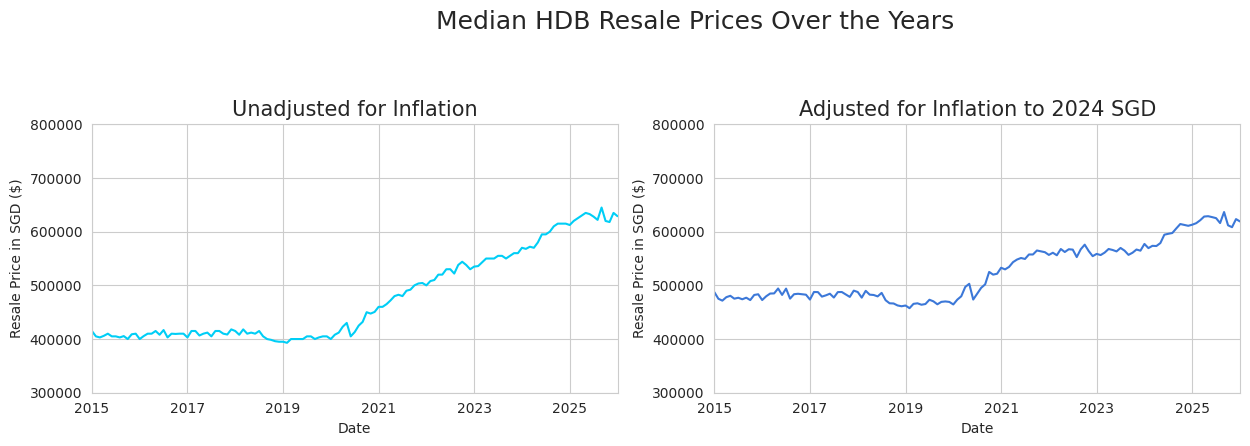

In [ ]:
# Plot Median Resale Prices Over the Years

# Unadjusted
fig = plt.figure(figsize=(14,4.5))
fig.suptitle('Median HDB Resale Prices Over the Years', fontsize=18)
ax1 = fig.add_subplot(121)
hdb_price.groupby('sale_date')[['resale_price']].median().plot(ax=ax1, color='#00cef6', legend=None)
ax1.set_xlabel('Date'), ax1.set_ylabel('Resale Price in SGD ($)'), ax1.set_ylim(300000, 800000), ax1.set_title('Unadjusted for Inflation', size=15)

# Adjusted
ax2 = fig.add_subplot(122)
hdb_price.groupby('sale_date')[['real_price']].median().plot(ax=ax2, color='#3c78d8', legend=None)
ax2.set_xlabel('Date'), ax2.set_ylabel('Resale Price in SGD ($)'), ax2.set_ylim(300000, 800000), ax2.set_title('Adjusted for Inflation to 2024 SGD',size=15)

plt.tight_layout(rect=[0, 0, 0.9, 0.9])
plt.show()

#### <font style = 'color:black'> 2. Distribution of HDB resale prices (Histogram and Boxplot) </font>

---

Why show Histogram and Box Plot for distribution of HDB resale prices?
- Histogram can see __frequency__ (E.g. the number of times it appears), and __shape__ (E.g. bell curve, peaks, gaps)
- Box Plot give us concise __statistical summary__ (E.g. median, quartiles and range)

#### 2a. Histogram

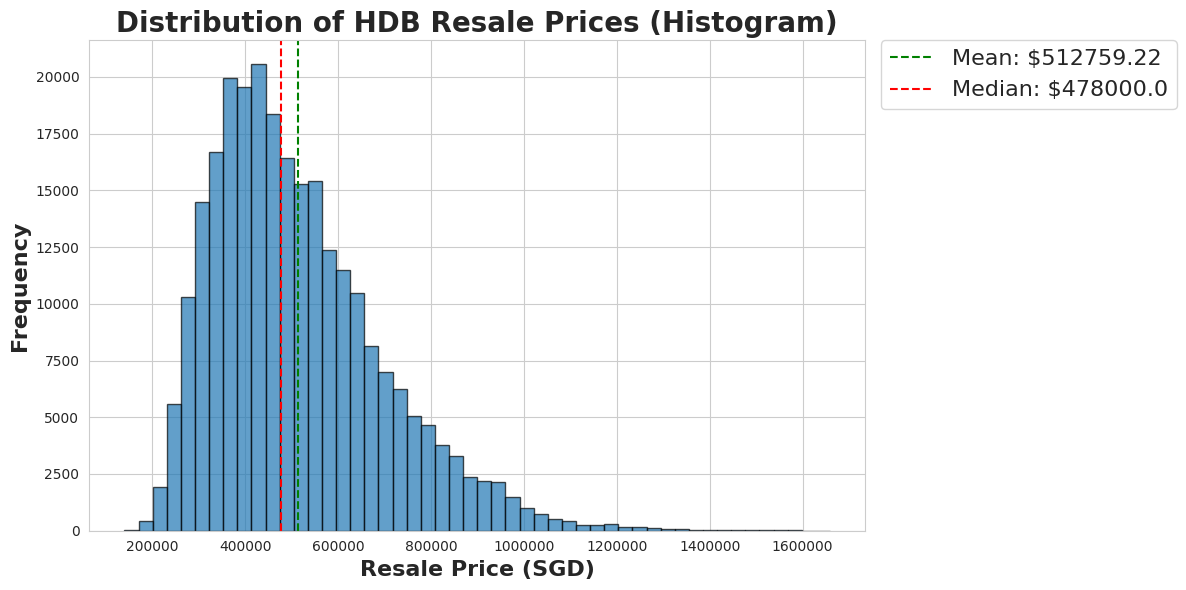

In [ ]:
# Distribution of HDB Resale Prices (Histogram)
plt.figure(figsize=(12,6))

# Plot using histogram
plt.hist(hdb_price['resale_price'], bins=50, edgecolor='black', alpha=0.7)

# Change title and labels
plt.xlabel('Resale Price (SGD)', fontsize=16, fontweight='bold')
plt.ticklabel_format(style='plain', axis='x') # Show the real value of resale prices, not in scientific notation
plt.ylabel('Frequency', fontsize=16, fontweight='bold')
plt.title('Distribution of HDB Resale Prices (Histogram)', fontsize=20, fontweight='bold')

# Calculate median and average value
mean_val = hdb_price['resale_price'].mean()
median_val = hdb_price['resale_price'].median()

# See median and average value line
plt.axvline(mean_val, color='green', linestyle='--', label=f'Mean: ${round(mean_val, 2)}')
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: ${round(median_val, 2)}')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=16)

plt.tight_layout()
plt.show()

What can we understand from the histogram?
- Most flats are in the lower-to-middle price range, __right-skewed distribution__
- Fewer expensive flats pull the tail to the right
- __Median__ is better than mean for representing 'typical' price

**IMPORTANT!** We need Linear Regression to be symmetric (centered)

Why?
- Extreme values in a skewed distribution can have a __disporportionate influence on the model's paramter estimates__ and lead to __biased coefficients__.


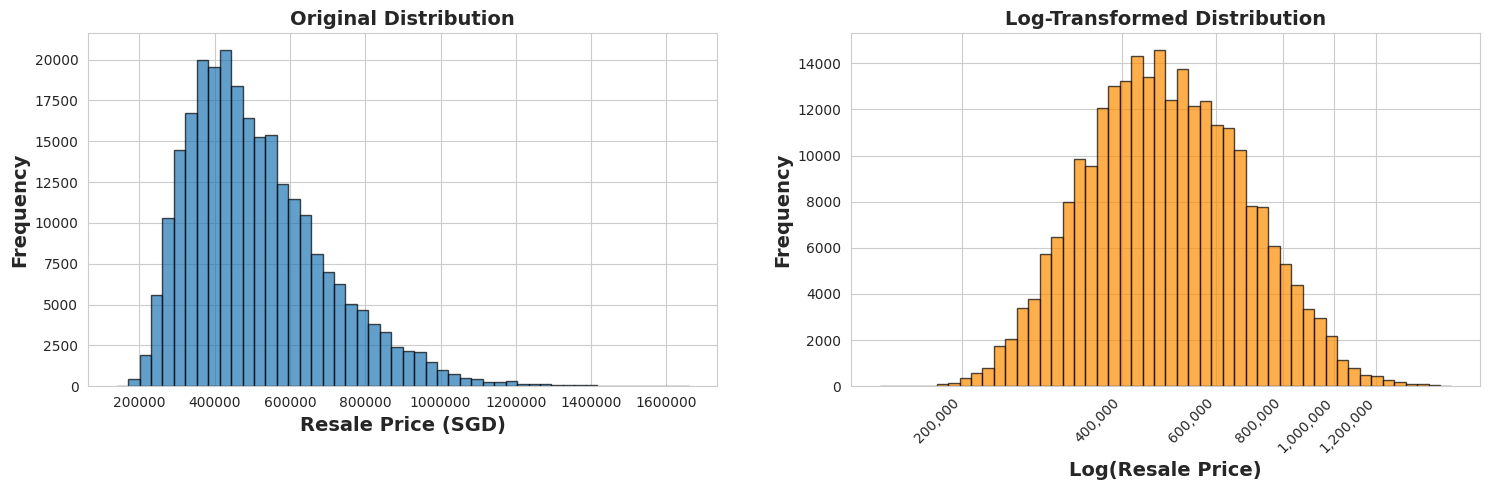

Original skewness: 1.024
Log-transformed skewness: 0.121


In [ ]:
# Check if log transformation helps
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Original
ax[0].hist(hdb_price['resale_price'], bins=50, edgecolor='black', alpha=0.7)
# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='x')
ax[0].set_xlabel('Resale Price (SGD)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax[0].set_title('Original Distribution', fontsize=14, fontweight='bold')

# Log-transformed
# np.log makes right skewed distribution more symmetric and normal shaped
ax[1].hist(np.log(hdb_price['resale_price']), bins=50, edgecolor='black', alpha=0.7, color='darkorange')
ax[1].set_xlabel('Log(Resale Price)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax[1].set_title('Log-Transformed Distribution', fontsize=14, fontweight='bold')

# Show consistency with the original distribution by adding ticks manually
# Define the human-readable prices you want to show
manual_ticks = [200000, 400000, 600000, 800000, 1000000, 1200000]
ax[1].set_xticks(np.log(manual_ticks))
# Set the labels to the ORIGINAL formatted prices
ax[1].set_xticklabels([f'{x:,}' for x in manual_ticks], rotation=45, ha='right') # Rotate as values are too clustered

plt.tight_layout(w_pad=4)
plt.show()

# Check skewness
print(f'Original skewness: {skew(hdb_price['resale_price']).round(3)}')
print(f'Log-transformed skewness: {skew(np.log(hdb_price['resale_price'])).round(3)}')

Using real price to analyze the distribution to understand the data before feeding it into my machine learning mode

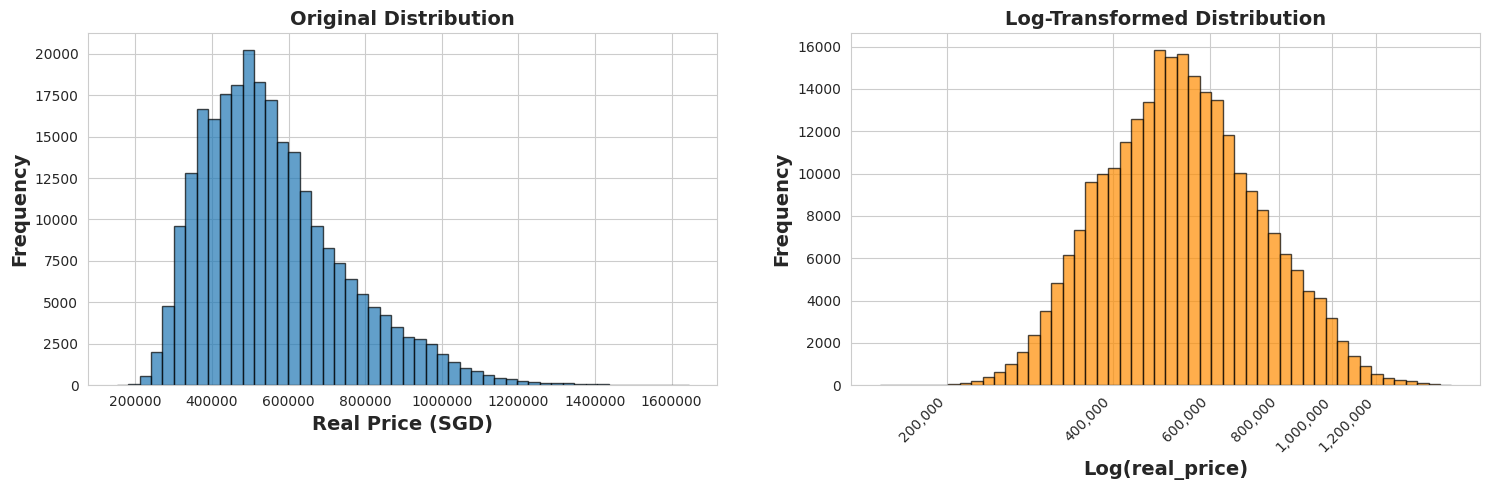

Original skewness: 0.984
Log-transformed skewness: 0.138


In [ ]:
# Check if log transformation helps
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Original
ax[0].hist(hdb_price['real_price'], bins=50, edgecolor='black', alpha=0.7)
# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='x')
ax[0].set_xlabel('Real Price (SGD)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax[0].set_title('Original Distribution', fontsize=14, fontweight='bold')

# Log-transformed
# np.log makes right skewed distribution more symmetric and normal shaped
ax[1].hist(np.log(hdb_price['real_price']), bins=50, edgecolor='black', alpha=0.7, color='darkorange')
ax[1].set_xlabel('Log(real_price)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax[1].set_title('Log-Transformed Distribution', fontsize=14, fontweight='bold')

# Show consistency with the original distribution by adding ticks manually
# Define the human-readable prices you want to show
manual_ticks = [200000, 400000, 600000, 800000, 1000000, 1200000]
ax[1].set_xticks(np.log(manual_ticks))
# Set the labels to the ORIGINAL formatted prices
ax[1].set_xticklabels([f'{x:,}' for x in manual_ticks], rotation=45, ha='right') # Rotate as values are too clustered

plt.tight_layout(w_pad=4)
plt.show()

# Check skewness
print(f'Original skewness: {skew(hdb_price['real_price']).round(3)}')
print(f'Log-transformed skewness: {skew(np.log(hdb_price['real_price'])).round(3)}')

What can we understand from this change?
- __Original Distribution (Left)__: It is right-skewed, most HDB prices are clustered at the lower end, with fewer, more extreme high-priced properties pulling the distribution's tail out. This is typical of real-world financial data.
- __Log_Transformed Distribution (Right)__: More symmterical, closely resembling a bell curve or normal distribution, useful for Linear Regression.

The purpose of log transformation is __data preprocessing for statistical analysis like Linear Regression__. The data becomes more suitable for these models, leading to more stable and reliable predictions.

#### 2b. Box Plot

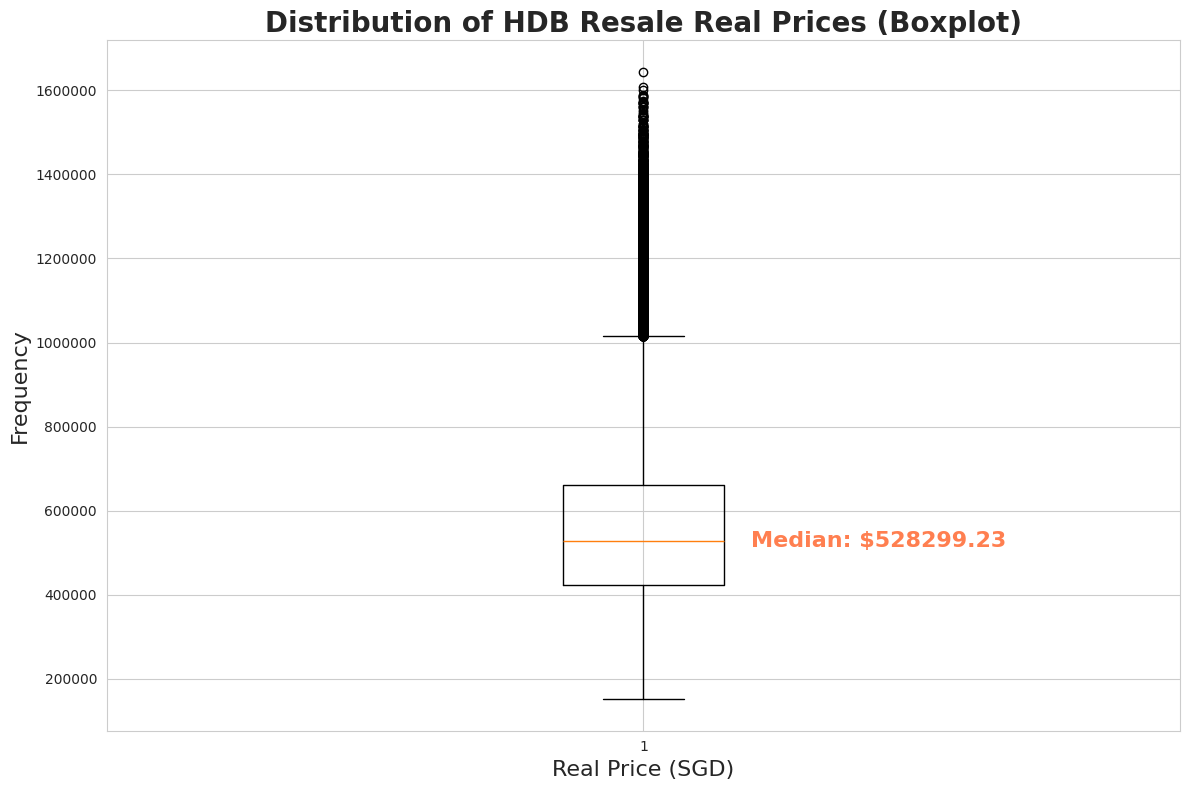

In [ ]:
# Distribution of HDB Resale Prices (Box Plot)
plt.figure(figsize=(12,8))

# Plot using boxplot
plt.boxplot(hdb_price['real_price'], vert=True) # vert=True plots the boxplot vertically

# Show the real value of prices
plt.ticklabel_format(style='plain', axis='y')

# Calculate and display the median value
median_val = hdb_price['real_price'].median()
plt.text(1.1, median_val, f'Median: ${round(median_val, 2)}',
        verticalalignment='center', fontsize=16, color='coral', fontweight='bold')

# Change title and labels
plt.xlabel('Real Price (SGD)', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title('Distribution of HDB Resale Real Prices (Boxplot)', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

What can we understand from this chart?
- Median Price: The typical HDB Actual price is **SGD528,000**.
- Main Range: Most sales (middle 50%) fall between **SGD420,000** and **SGD680,000**.
- Extreme Outliers: Many high-value flats sell for over **SGD1.0 million** with some reaching **SGD1.6 million+**.




Overall, the chart illustrates that while the typical price is **SGD528,000**, there is a wide range of values, including numerous highly expensive transactions.

#### <font style = 'color:black'> 3. Price trends over time </font>

---

Use resale price here instead of real price (factoring Inflation) to see the price trends throughout the years.

In [ ]:
# Group by Transaction month
price_by_yr = hdb_price.groupby('year')['resale_price'].agg(['mean', 'median', 'count'])
print(price_by_yr)

               mean    median  count
year                                
2015  434752.756281  405000.0  17756
2016  438873.443609  410000.0  19349
2017  443750.749626  410000.0  20316
2018  441306.499304  408000.0  21537
2019  432206.984231  400000.0  22155
2020  452388.607417  425000.0  23288
2021  511533.409608  483000.0  29020
2022  549765.356505  525000.0  26672
2023  571930.563863  550000.0  25718
2024  612614.794408  590000.0  27806
2025  652531.013421  628000.0  25073
2026  657072.923913  628888.0   1329


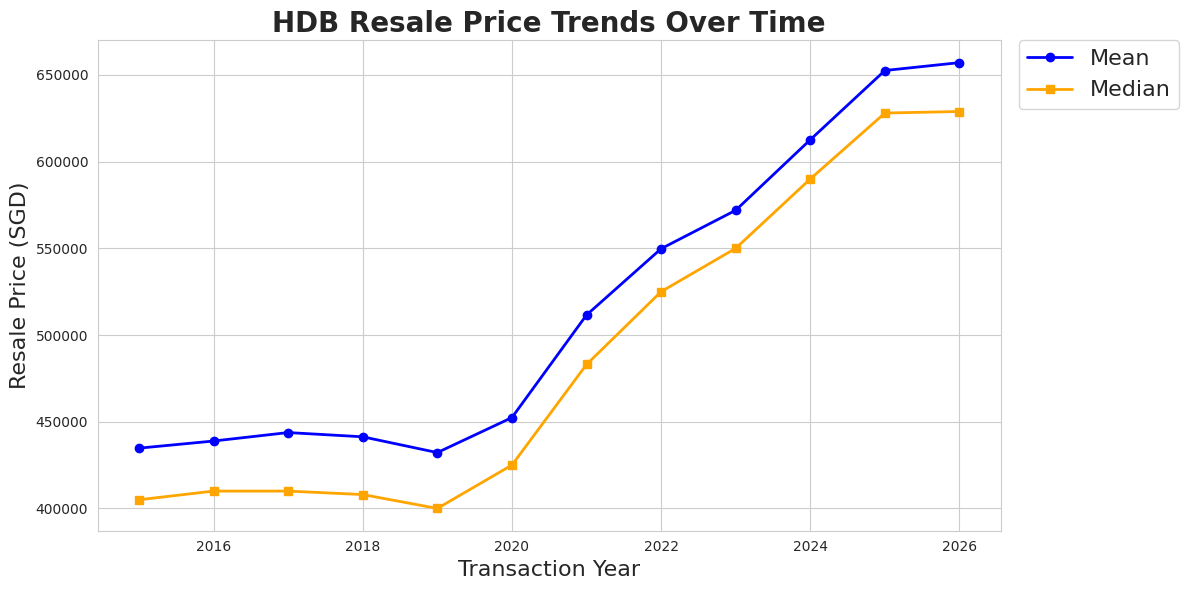

In [ ]:
# Plot price trends
plt.figure(figsize=(12,6))
plt.plot(price_by_yr.index, price_by_yr['mean'], color='blue', marker='o', label='Mean', linewidth=2)
plt.plot(price_by_yr.index, price_by_yr['median'], color='orange',  marker='s', label='Median', linewidth=2)

# Change title and labels
plt.xlabel('Transaction Year', fontsize=16)
plt.ylabel('Resale Price (SGD)', fontsize=16)
plt.title('HDB Resale Price Trends Over Time', fontsize=20, fontweight='bold')

# Add legend
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=16)

plt.tight_layout()
plt.show()

What can we understand from the trend?
- 2015 to 2018 slight rise: Market stabilization from previous goverment cooling measures
- 2018 to 2019 dip: More cooling measures, economic uncertainty
- 2019 to 2020 slight rise: Market stabilization from previous goverment cooling measures
- 2020 to 2025 steep rise: COVID-19 boom, low interest rates, limited supply
- 2025 market stablising: The deceleration is attributed to a steady supply of new BTO and SBF flats, government cooling measures, and a more cautious market sentiment.

#### <font style = 'color:black'> 4. Check for outliers using interquartile range (IQR) Method </font>

---


In [ ]:
Q1 = hdb_price['resale_price'].quantile(0.25) # Take top 25%
Q3 = hdb_price['resale_price'].quantile(0.75) # Take top 75%

# IQR Method (How it works)
IQR = Q3 - Q1 # Find the IQR
lower_bound = Q1 - 1.5 * IQR # Set lower fences
upper_bound = Q3 + 1.5 * IQR # Set upper fences

# Identify Outliers
outliers = hdb_price[(hdb_price['resale_price'] < lower_bound) | (hdb_price['resale_price'] > upper_bound)]

# print top 10 selected columns
if len(outliers) > 0:
    print(outliers[['flat_type', 'floor_area_sqm', 'resale_price', 'town']].head(10))
    print(f'\n{outliers.shape}') # 5257 rows, 38 columns

      flat_type  floor_area_sqm  resale_price             town
349      5 ROOM           106.0      980000.0     CENTRAL AREA
1534  EXECUTIVE           146.0      980000.0      BUKIT TIMAH
1553     5 ROOM           107.0      991000.0     CENTRAL AREA
1554     5 ROOM           105.0     1000000.0     CENTRAL AREA
1555     5 ROOM           107.0     1030000.0     CENTRAL AREA
1556     5 ROOM           105.0     1040000.0     CENTRAL AREA
2012     5 ROOM           147.0      985000.0       QUEENSTOWN
2773     5 ROOM           105.0      973888.0     CENTRAL AREA
2774     5 ROOM           107.0     1018000.0     CENTRAL AREA
3113     3 ROOM           280.0     1060000.0  KALLANG/WHAMPOA

(5231, 45)


In [ ]:
#percentage of outliers over full dataset

percentage = (5257 / 260233) * 100
print(f"{percentage:.2f}%")

2.02%


There are **5257 outliers**, which is **2.02%** of the full dataset.

**DECISION: Keep them. Why?**

*   They are real transactions of executive flats, prime locations, penthouses
*   Removing them loses valuable data
*   The model should learn to predict high-value properties too




In [ ]:
# Other information
print(f"Lower bound: ${round(lower_bound, 0)}")
print(f"Upper bound: ${round(upper_bound, 0)}")
print(f"Min price: ${round(hdb_price['resale_price'].min(), 0)}")
print(f"Max price: ${round(hdb_price['resale_price'].max(), 0)}")

Lower bound: $21168.0
Upper bound: $972720.0
Min price: $140000.0
Max price: $1658888.0


## <font style = 'color:black'>003b - Exploratory Data Analysis (EDA) Phase 2</font>
---
We explore the **categorical** & **numerical** features and understand its distribution and trends.

We have identified __4__ categorical features:
- Flat Type
- Flat Model
- Storey Range
- Planning Area

We have identified 5 Numerical features:
- Floor area
- Lease commence date
- Distance to nearest amenities
- Number of Amenities in 1km Radius
- Number of Schools in 2km Radius

1. Flat Type Analysis
  >*   Which flat types are most expensive?
  >*   Which flat type have the highest floor area sqm?

2. Flat Type & Model Analysis
  >*   which flat model are most expensive?
  >*   Which flat model have the highest floor area sqm?

3. Floor area Analysis (Is higher floor area more expensesive?)
4. Storey range analysis (Does storey range affects pricing?)
5. Planning Area Analysis (which locations are premium? Which town is older?)
6. Lease commence date Analysis
7. Distance to nearest amenities Analysis
8. Number of amenities in 1km radius Analysis (Does the amount of amenities within 10 to 15 min walking time affect the price?) (see power BI)
9. School and top school analysis (Buying a flat near top primary school make a difference?) (see power BI)
10. MRT and MRT interchange analysis
(see power BI)



#### <font style = 'color:black'> 1. Flat Type Analysis (which types are most expensive?) </font>

---

In [ ]:
# Understand our flat type data with summary statistics
# For display, mean and std is not used
flat_type_stats = hdb_price.groupby('flat_type')['real_price'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

# Sort by median
flat_type_stats = flat_type_stats.sort_values('median', ascending=False)
flat_type_stats

,count,mean,median,std,min,max
flat_type,,,,,,
MULTI-GENERATION,89,951899.946292,944558.52,113859.343526,690647.48,1375436.23
EXECUTIVE,18850,790224.404660,772546.72,147598.593686,456339.27,1580933.23
5 ROOM,63420,669935.719778,632392.55,171611.458262,313701.80,1644091.18
4 ROOM,109628,564234.577609,528727.53,151655.439945,253818.93,1536176.97
3 ROOM,63056,399333.567876,379779.68,96751.413666,152628.26,1570858.96
2 ROOM,4882,316079.133767,314420.74,52239.600470,151244.74,610587.14
1 ROOM,94,234694.064894,239484.92,24438.184274,182170.50,298843.48


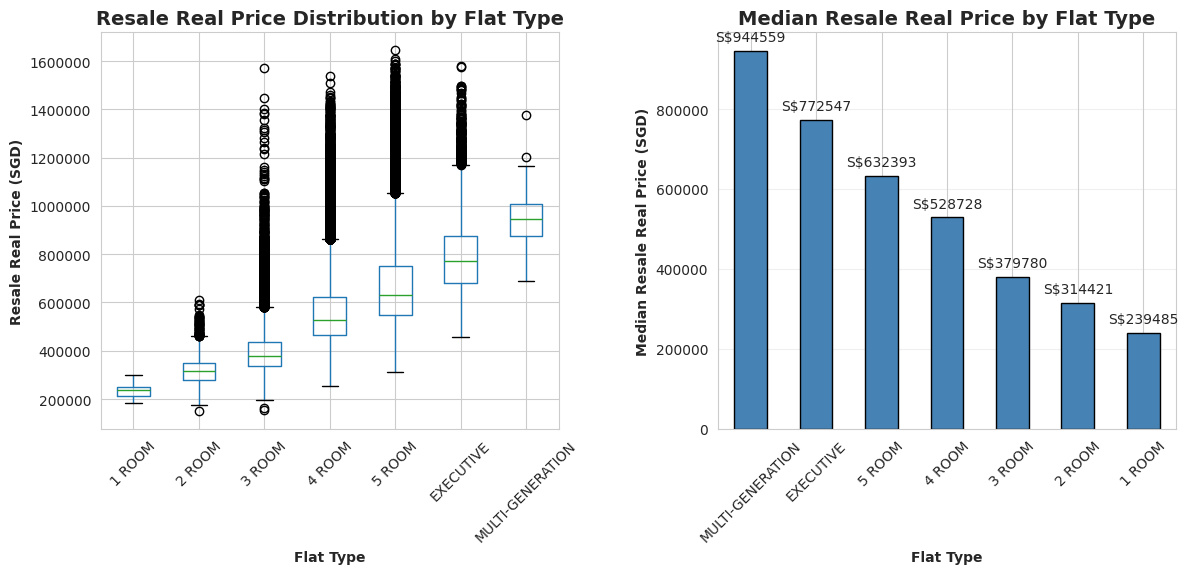

In [ ]:
# Which flat type is more expensive? - Visualisation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

## FIRST CHART
# Box Plot -- Resale Price Distribution by flat_type (Left)
hdb_price.boxplot(column='real_price', by='flat_type', ax=ax[0])

# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[0].set_title('Resale Real Price Distribution by Flat Type', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Flat Type', fontweight='bold')
ax[0].set_ylabel('Resale Real Price (SGD)', fontweight='bold')

# Rotate x-axis labels for the left subplot
ax[0].tick_params(axis='x', rotation=45)

## =================================================================================
## SECOND CHART (Median)
# Bar chart -- Median Resale Real Price by flat_type (Right)
flat_type_stats['median'].plot(kind='bar', ax=ax[1], color='steelblue', edgecolor='black')

# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[1].set_title('Median Resale Real Price by Flat Type', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Flat Type', fontweight='bold')
ax[1].set_ylabel('Median Resale Real Price (SGD)', fontweight='bold')

# Rotate x-axis labels for the top-left subplot
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

# Show data values
ax[1].bar_label(ax[1].containers[0], padding=5, fmt='S$%.0f')

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout(w_pad=4) # They are too close together, w_pad means width padding adjusted to 4.
plt.show()

What can we understand from these charts?
- __Price range increases with flat type(see chart on the left)__:

> When focusing on main range of resale Real price
>* We can see that the price range increase with flat type
>* Flat types like 1-3 Room have consistent prices, while larger flats like 4-5 Room show huge variation.

> When looking at outliers
>* 3 - 5 room & executive flats have the significant outliers
>* 3 room flats have the larger outliers range, likely due to the flat model & floor area sqm difference for 3 room flat.

- __Price Hierarchy (see chart on the right)__:

Multi-Generation flats have the __highest median resale price__, whereas 1 room flats have the __lowest median price__.


Overall, **flat type** is a critical factor affecting HDB resale prices, however we need to to investigate the **flat model and flat size** in each flat type as it is likely that the **flat model and flat size** will **highly affect** the HDB resale price.

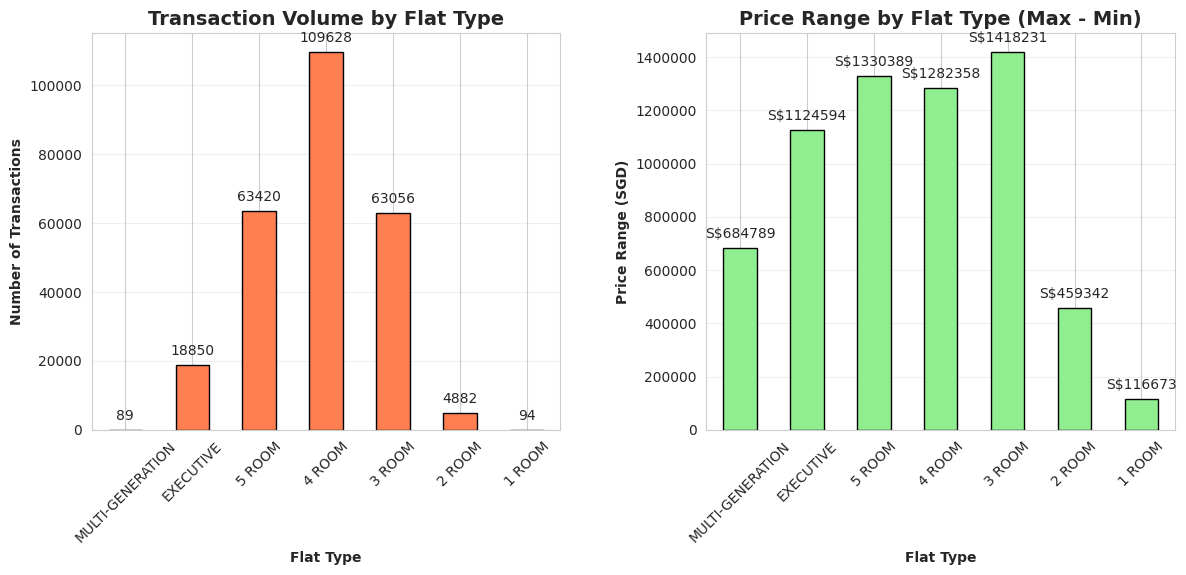

In [ ]:
# Which flat type have highest transactional volume and price range?
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

## FIRST CHART (Count)
# Bar Chart -- Transaction Volume by Flat Type (Left)
flat_type_stats['count'].plot(kind='bar', ax=ax[0], color='coral', edgecolor='black')

# Set titles and labels
ax[0].set_title('Transaction Volume by Flat Type', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Flat Type', fontweight='bold')
ax[0].set_ylabel('Number of Transactions', fontweight='bold')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', alpha=0.3)

## =================================================================================
## SECOND CHART (Max - Min)
# Bar chart -- Price range by flat type (max - min) (Right)
price_range = flat_type_stats['max'] - flat_type_stats['min']
price_range.plot(kind='bar', ax=ax[1], color='lightgreen', edgecolor='black')

# Show the real value of resale prices, not in scientific notation
ax[1].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[1].set_title('Price Range by Flat Type (Max - Min)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Flat Type', fontweight='bold')
ax[1].set_ylabel('Price Range (SGD)', fontweight='bold')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

# Show data values
ax[0].bar_label(ax[0].containers[0], padding=5, fmt='%.0f')
ax[1].bar_label(ax[1].containers[0], padding=5, fmt='S$%.0f')

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout(w_pad=4) # They are too close together, w_pad means width padding adjusted to 4.
plt.show()

In [ ]:
# Understand our flat type data with summary statistics
# For display, mean and std is not used
flat_type_size = hdb_price.groupby('flat_type')['floor_area_sqm'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

# Sort by median
flat_type_size = flat_type_size.sort_values('median', ascending=False)
flat_type_size

,count,mean,median,std,min,max
flat_type,,,,,,
MULTI-GENERATION,89,161.168539,164.0,12.954673,132.0,179.0
EXECUTIVE,18850,144.683501,146.0,10.530669,124.0,243.0
5 ROOM,63420,117.810013,117.0,7.354794,99.0,167.0
4 ROOM,109628,95.163211,93.0,7.083293,70.0,176.0
3 ROOM,63056,68.195550,67.0,6.477811,51.0,366.7
2 ROOM,4882,45.688243,47.0,3.465211,34.0,67.0
1 ROOM,94,31.000000,31.0,0.000000,31.0,31.0


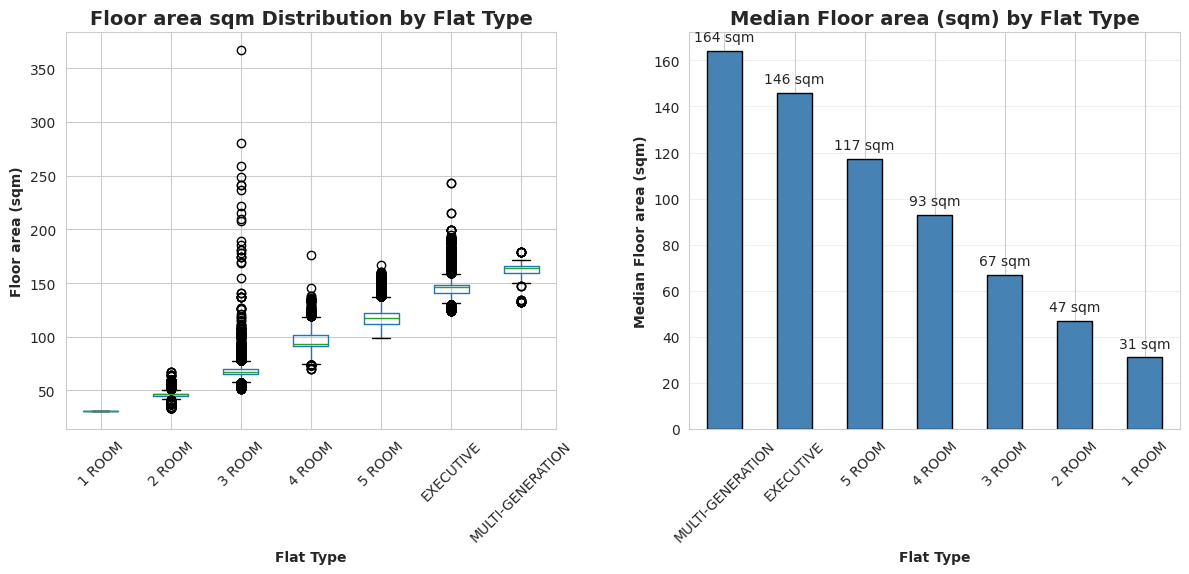

In [ ]:
# Which flat type have highest floor area sqm? - Visualisation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

## FIRST CHART
# Box Plot -- floor area sqm Distribution by flat_type (Left)
hdb_price.boxplot(column='floor_area_sqm', by='flat_type', ax=ax[0])

# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[0].set_title('Floor area sqm Distribution by Flat Type', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Flat Type', fontweight='bold')
ax[0].set_ylabel('Floor area (sqm)', fontweight='bold')

# Rotate x-axis labels for the left subplot
ax[0].tick_params(axis='x', rotation=45)

## =================================================================================
## SECOND CHART (Median)
# Bar chart -- Median Resale Price by flat_type (Right)
flat_type_size['median'].plot(kind='bar', ax=ax[1], color='steelblue', edgecolor='black')

# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[1].set_title('Median Floor area (sqm) by Flat Type', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Flat Type', fontweight='bold')
ax[1].set_ylabel('Median Floor area (sqm)', fontweight='bold')

# Rotate x-axis labels for the top-left subplot
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

# Show data values
ax[1].bar_label(ax[1].containers[0], padding=5, fmt='%.0f sqm')

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout(w_pad=4) # They are too close together, w_pad means width padding adjusted to 4.
plt.show()

What can we understand from these charts?
- __Dominant Flat Type 4-room flats (see "Transaction Volume by Flat Type")__: Most popular HDB flat type for resale, showing the highest number of transactions, exceeding __100,000 units__. High demand mentions are 5 Room and 3 Room flats, while low demand mentions are Multi Gen, 1 Room and 2 Room flats.
- __Flat-Price Correlation (see "Price Range by Flat Type (Max - Min)")__: As flat size increase, potential price range also increase like for Executive, 3 Room, 4 Room and 5 Room flats, which all show ranges exceeding **SGD$1,200,000**. Multi-Generation flats have a smaller transaction range than these mid-size units.

Overall, __4 Room__ flats are the most actively traded. Those mid-to-large flats (E.g. 3-5 Room & executive) have the largest price range.



Seems like 3 room flats have large amount of extreme outliers.

Need to zoom into 3room flats >90 sqm to investigate outliers:

*   Lease commence year (does older flats have larger sqm)
*   Which flat models of 3 room flats have higher sqm?

/tmp/ipykernel_5866/3935898614.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3room, x='flat_model', y='lease_commence_date', palette='Set2')


                   count                           mean                  min  \
flat_model                                                                     
DBSS                 502  2013-07-13 23:14:06.215139328  2011-01-01 00:00:00   
Improved           15535  1976-03-07 20:47:28.484068224  1966-01-01 00:00:00   
Model A            17687  2001-09-01 08:17:41.661106816  1982-01-01 00:00:00   
New Generation     21513  1981-03-04 05:18:28.966671360  1975-01-01 00:00:00   
Premium Apartment   1379  2015-09-03 14:40:17.403915776  2012-01-01 00:00:00   
Simplified          2804  1987-02-24 07:06:14.893010048  1985-01-01 00:00:00   
Standard            3508  1970-04-17 11:51:47.411630558  1967-01-01 00:00:00   
Terrace              128            1971-06-09 13:07:30  1968-01-01 00:00:00   

                                   max  
flat_model                              
DBSS               2015-01-01 00:00:00  
Improved           1994-01-01 00:00:00  
Model A            2021-01-01 00:00

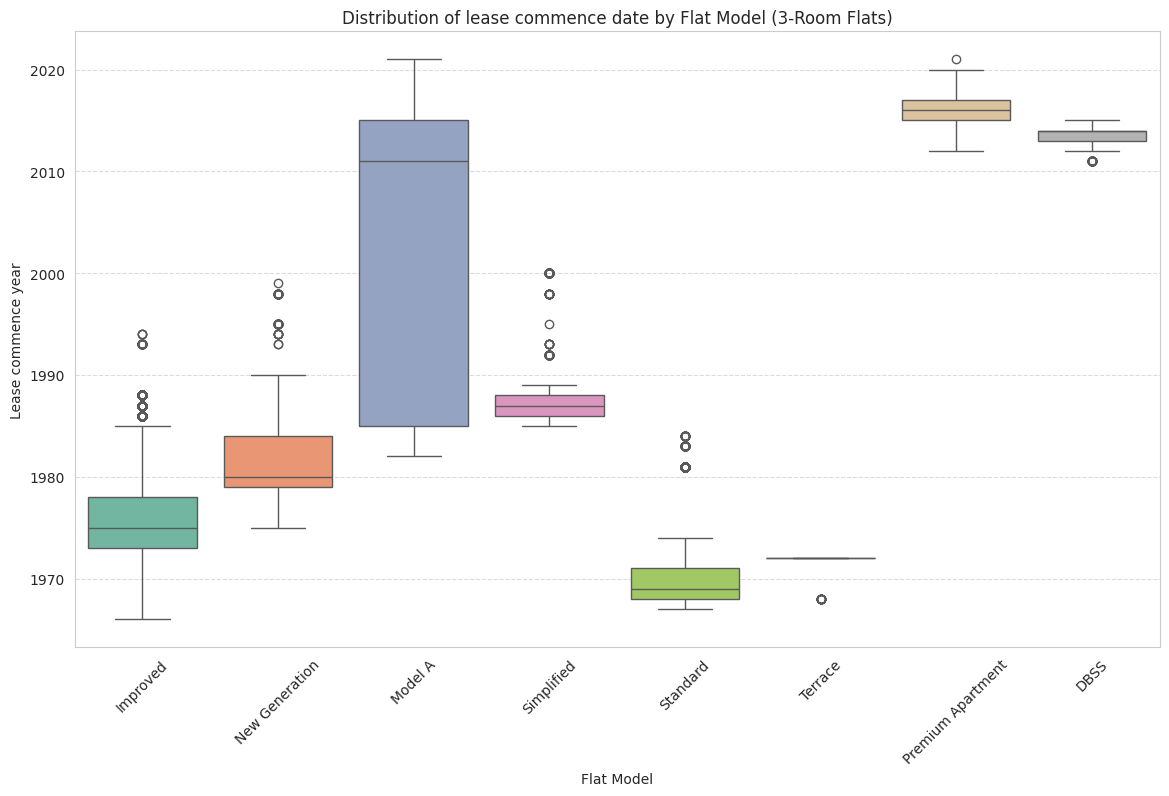

In [ ]:
# Filter for 3-Room flats lease commencement date
df_3room = hdb_price[hdb_price['flat_type'] == '3 ROOM']

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_3room, x='flat_model', y='lease_commence_date', palette='Set2')
plt.title('Distribution of lease commence date by Flat Model (3-Room Flats)')
plt.xlabel('Flat Model')
plt.ylabel('Lease commence year')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Calculate summary statistics to display
summary = df_3room.groupby('flat_model')['lease_commence_date'].describe()[['count', 'mean', 'min', 'max']]
print(summary)

/tmp/ipykernel_5866/810570471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3room, x='flat_model', y='floor_area_sqm', palette='Set2')


                     count        mean   min    max
flat_model                                         
DBSS                 502.0   65.262948  60.0   70.0
Improved           15535.0   65.309752  57.0  137.0
Model A            17687.0   70.403008  60.0  104.0
New Generation     21513.0   70.000651  66.0  107.0
Premium Apartment   1379.0   67.535170  62.0   73.0
Simplified          2804.0   64.332026  63.0   82.0
Standard            3508.0   60.816192  51.0   88.0
Terrace              128.0  115.518750  78.0  366.7


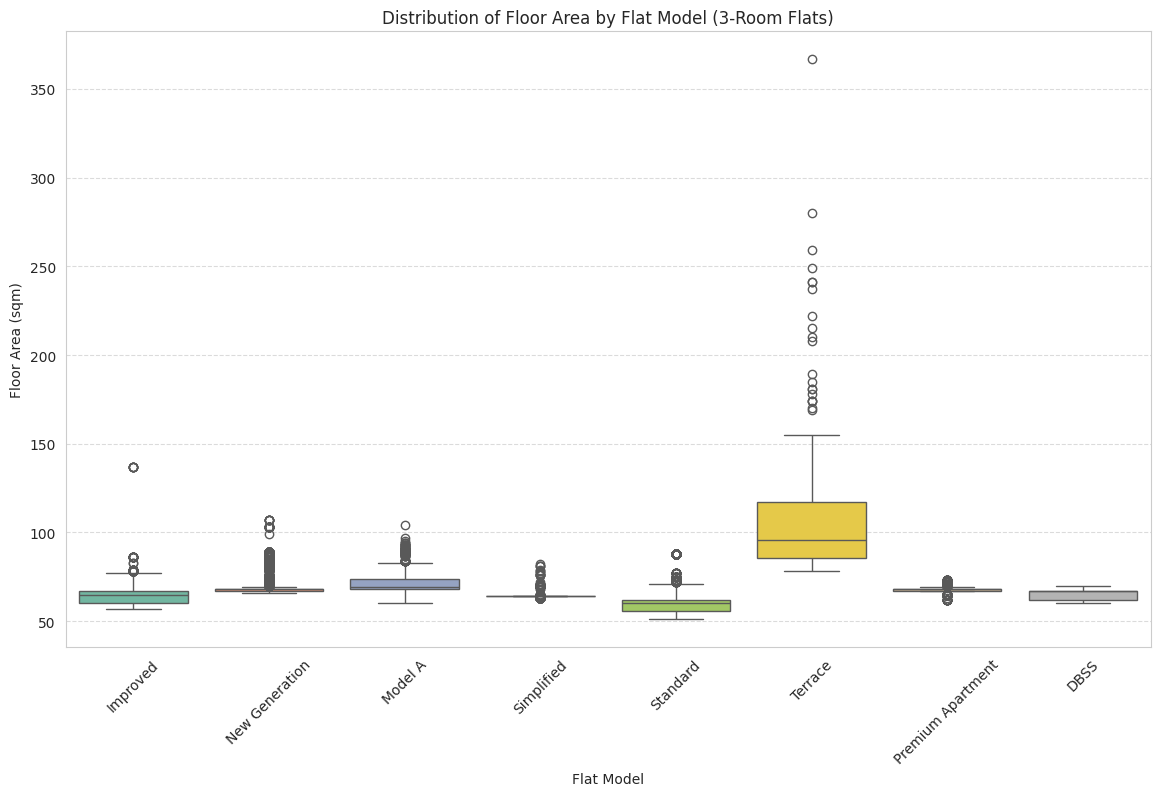

In [ ]:
# Filter for 3-Room flats
df_3room = hdb_price[hdb_price['flat_type'] == '3 ROOM']

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_3room, x='flat_model', y='floor_area_sqm', palette='Set2')
plt.title('Distribution of Floor Area by Flat Model (3-Room Flats)')
plt.xlabel('Flat Model')
plt.ylabel('Floor Area (sqm)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Calculate summary statistics to display
summary = df_3room.groupby('flat_model')['floor_area_sqm'].describe()[['count', 'mean', 'min', 'max']]
print(summary)

       lease_commence_date  floor_area_sqm               address  \
2972            1966-01-01            67.0      39 TEBAN GDNS RD   
113525          1966-01-01            67.0      39 TEBAN GDNS RD   
53003           1966-01-01            67.0      37 TEBAN GDNS RD   
217444          1966-01-01            67.0      39 TEBAN GDNS RD   
94325           1966-01-01            67.0      39 TEBAN GDNS RD   
...                    ...             ...                   ...   
235213          2021-01-01            69.0     431A BEDOK NTH RD   
250598          2021-01-01            68.0  355A ANCHORVALE LANE   
254773          2021-01-01            68.0   102B BIDADARI PK DR   
235216          2021-01-01            69.0     429B BEDOK NTH RD   
247265          2021-01-01            67.0    406B NORTHSHORE DR   

        resale_price  real_price  
2972        260000.0   304225.22  
113525      228000.0   265774.53  
53003       200000.0   235668.41  
217444      335000.0   332800.19  
94325   

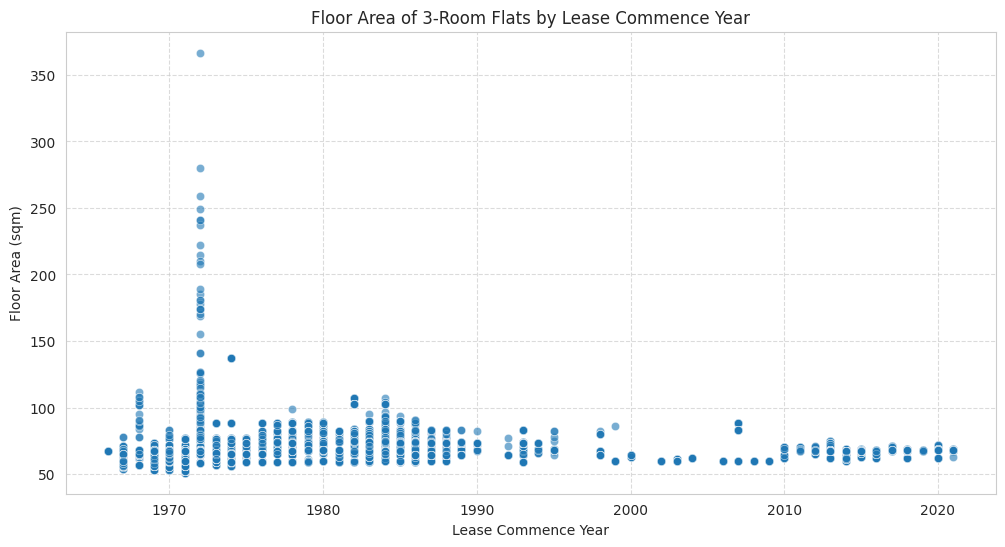

In [ ]:
# Filter for 3-Room flats
df_3room= hdb_price[(hdb_price['flat_type'] == '3 ROOM')]

# Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_3room, x='lease_commence_date', y='floor_area_sqm', alpha=0.6)
plt.title('Floor Area of 3-Room Flats by Lease Commence Year')
plt.xlabel('Lease Commence Year')
plt.ylabel('Floor Area (sqm)')
plt.grid(True, linestyle='--', alpha=0.7)

# Show summary statistics
print(df_3room[['lease_commence_date', 'floor_area_sqm', 'address', 'resale_price','real_price']].sort_values(by='lease_commence_date'))
print(f"\nUnique Lease Commence Years for these flats: {sorted(df_3room['lease_commence_date'].unique())}")

/tmp/ipykernel_5866/4272097992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3room_large, x='flat_model', y='floor_area_sqm', palette='Set2')


                count        mean    min    max
flat_model                                     
Improved          6.0  137.000000  137.0  137.0
Model A          19.0   93.473684   91.0  104.0
New Generation   41.0  103.487805   99.0  107.0
Terrace          83.0  133.271084   90.3  366.7


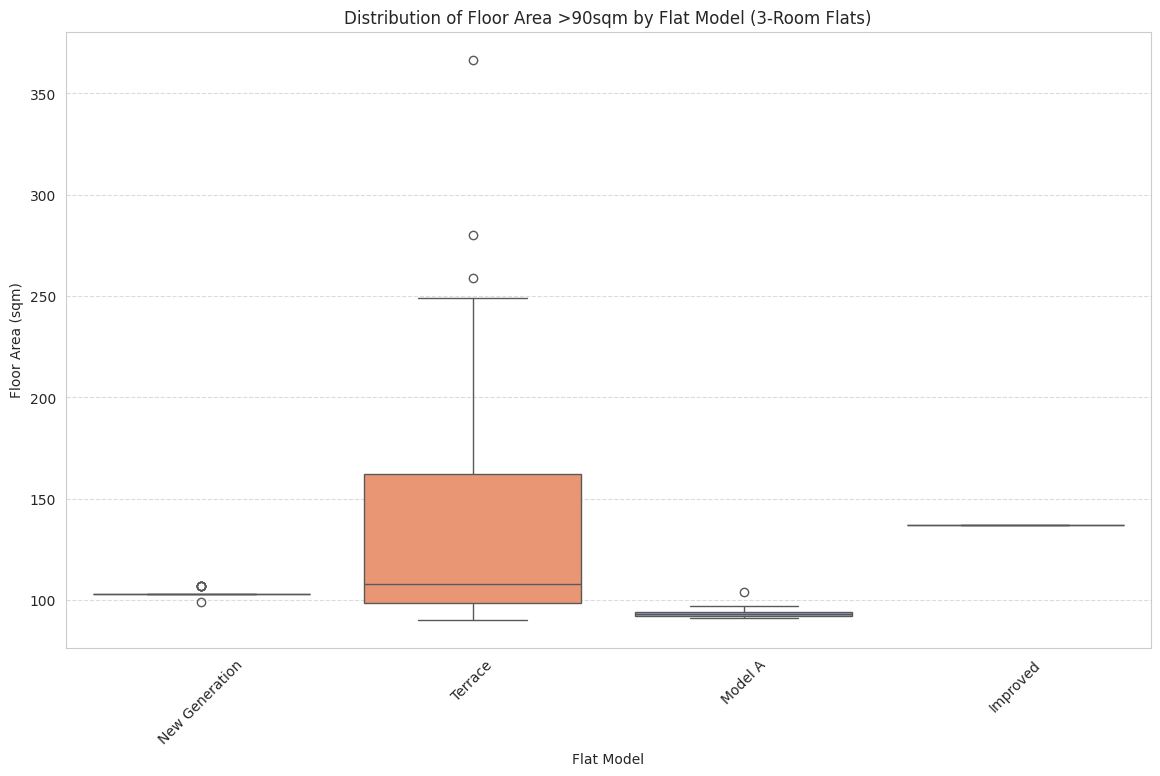

In [ ]:
# Filter for 3-Room flats & > 90sqm (Above the max of DBSS, Premium Apartment, Simplified, and Standard)
df_3room_large = hdb_price[(hdb_price['flat_type'] == '3 ROOM') & (hdb_price['floor_area_sqm'] > 90)]

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_3room_large, x='flat_model', y='floor_area_sqm', palette='Set2')
plt.title('Distribution of Floor Area >90sqm by Flat Model (3-Room Flats)')
plt.xlabel('Flat Model')
plt.ylabel('Floor Area (sqm)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Calculate summary statistics to display
summary = df_3room_large.groupby('flat_model')['floor_area_sqm'].describe()[['count', 'mean', 'min', 'max']]
print(summary)

/tmp/ipykernel_5866/4072596259.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3room_large, x='flat_model', y='lease_commence_date', palette='Set2')


               count                           mean                  min  \
flat_model                                                                 
Improved           6            1974-01-01 00:00:00  1974-01-01 00:00:00   
Model A           19  1984-06-02 22:44:12.631578944  1983-01-01 00:00:00   
New Generation    41  1982-08-02 15:13:10.243902464  1978-01-01 00:00:00   
Terrace           83  1971-07-08 23:25:18.072289160  1968-01-01 00:00:00   

                                max  
flat_model                           
Improved        1974-01-01 00:00:00  
Model A         1986-01-01 00:00:00  
New Generation  1984-01-01 00:00:00  
Terrace         1972-01-01 00:00:00  


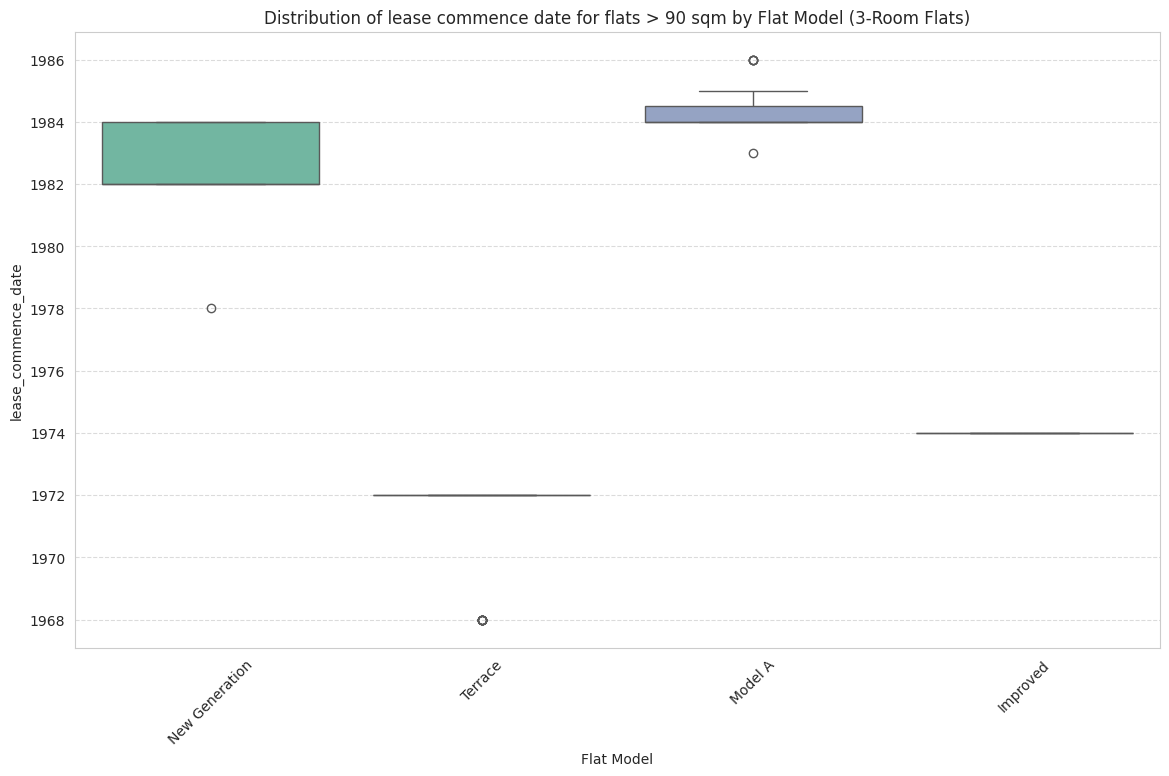

In [ ]:
# Filter for 3-Room flats & > 90sqm (Above the max of DBSS, Premium Apartment, Simplified, and Standard)
df_3room_large = hdb_price[(hdb_price['flat_type'] == '3 ROOM') & (hdb_price['floor_area_sqm'] > 90)]

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_3room_large, x='flat_model', y='lease_commence_date', palette='Set2')
plt.title('Distribution of lease commence date for flats > 90 sqm by Flat Model (3-Room Flats)')
plt.xlabel('Flat Model')
plt.ylabel('lease_commence_date')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Calculate summary statistics to display
summary = df_3room_large.groupby('flat_model')['lease_commence_date'].describe()[['count', 'mean', 'min', 'max']]
print(summary)

What can we understand from these charts?
- **3 room Terrace** have a **wider and higher** Main range of **floor area** : Likely these higher floor areas allow these flats to fetched higher prices.
- **Older 3room flats tend to be larger in sqm**: 3 room Terrace tend to be older, hence larger

Best to analysis by combining Flat type and model as a feature.

#### <font style = 'color:black'> 2. Flat Type & Model Analysis (which model are most expensive?) </font>

---

In [ ]:
# Combine 'flat_type' and 'flat_model' into a new column
hdb_price['flat_type_model'] = hdb_price['flat_type'] + ' ' + hdb_price['flat_model']

# Display the result
print("Preview of the new combined column:")
print(hdb_price[['flat_type', 'flat_model', 'flat_type_model']].head(10))

print("\nTop 10 most common combinations:")
print(hdb_price['flat_type_model'].value_counts().head(10))

# Understand our flat model data with summary statistics, round(2) to show values without scientific notations
model_stats = hdb_price.groupby('flat_type_model')['real_price'].agg(['count', 'mean', 'median']).round(2)

# Sort by median
model_stats = model_stats.sort_values('median', ascending=False)
model_stats # Uncomment if you want to see the whole thing.

Preview of the new combined column:
  flat_type      flat_model        flat_type_model
0    3 ROOM        Improved        3 ROOM Improved
1    3 ROOM  New Generation  3 ROOM New Generation
2    3 ROOM  New Generation  3 ROOM New Generation
3    3 ROOM  New Generation  3 ROOM New Generation
4    3 ROOM  New Generation  3 ROOM New Generation
5    3 ROOM  New Generation  3 ROOM New Generation
6    3 ROOM  New Generation  3 ROOM New Generation
7    3 ROOM  New Generation  3 ROOM New Generation
8    3 ROOM  New Generation  3 ROOM New Generation
9    3 ROOM  New Generation  3 ROOM New Generation

Top 10 most common combinations:
flat_type_model
4 ROOM Model A              67021
5 ROOM Improved             44737
3 ROOM New Generation       21513
3 ROOM Model A              17687
3 ROOM Improved             15535
4 ROOM Premium Apartment    14684
4 ROOM New Generation       12080
5 ROOM Premium Apartment     9906
EXECUTIVE Apartment          9444
4 ROOM Simplified            7616
Name: count, 

,count,mean,median
flat_type_model,,,
5 ROOM Type S2,241,1262229.94,1242377.87
4 ROOM Type S1,498,1128499.07,1092372.25
5 ROOM Premium Apartment Loft,31,1141267.85,1085387.55
4 ROOM Premium Apartment Loft,97,1083343.28,1062019.66
4 ROOM Terrace,10,1042767.04,1031078.46
5 ROOM DBSS,1742,1021546.34,983869.63
3 ROOM Terrace,128,976524.18,952460.39
MULTI-GENERATION Multi Generation,89,951899.95,944558.52
EXECUTIVE Adjoined flat,151,938019.38,941686.09


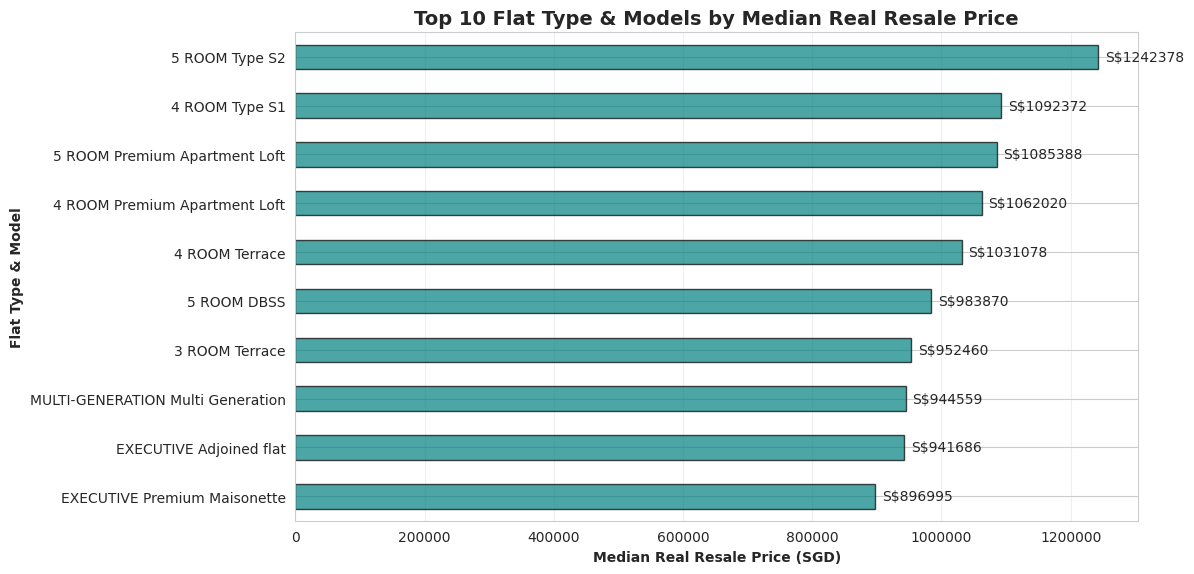

In [ ]:
# Visualise Flat type & model median real price - Top 10
plt.figure(figsize=(12, 6))

# Horizontal Bar Chart -- Top 10 Flat Models by Median Resale Price
model_stats.head(10)['median'].plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)

# Show the real value of resale prices, not in scientific notation
plt.ticklabel_format(style='plain', axis='x')

# Set titles and labels
plt.xlabel('Median Real Resale Price (SGD)', fontweight='bold')
plt.ylabel('Flat Type & Model', fontweight='bold')
plt.title('Top 10 Flat Type & Models by Median Real Resale Price', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Show data values
ax = plt.gca() # Get current axes object
ax.bar_label(ax.containers[0], padding=5, fmt='S$%.0f') # Adds labels with 0 decimal places and 5 points padding

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout()
plt.show()

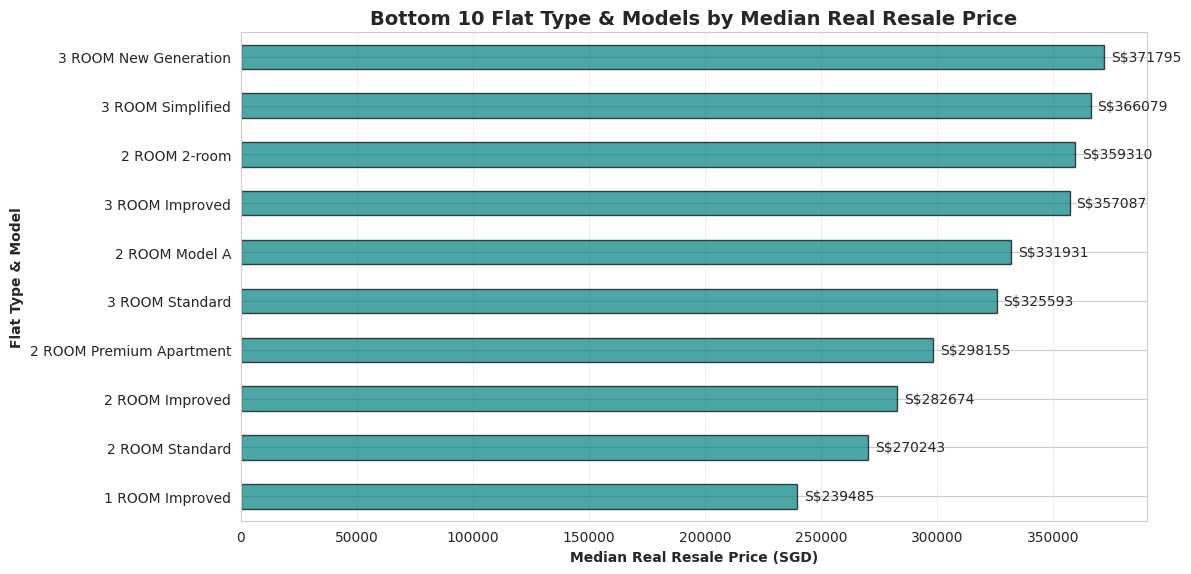

In [ ]:
# Visualise Flat type & model median real price - Bottom 10
plt.figure(figsize=(12, 6))

# Horizontal Bar Chart -- Bottom 10 Flat Models by Median Real Resale Price
model_stats.tail(10)['median'].plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)

# Show the real value of resale prices, not in scientific notation
plt.ticklabel_format(style='plain', axis='x')

# Set titles and labels
plt.xlabel('Median Real Resale Price (SGD)', fontweight='bold')
plt.ylabel('Flat Type & Model', fontweight='bold')
plt.title('Bottom 10 Flat Type & Models by Median Real Resale Price', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Show data values
ax = plt.gca() # Get current axes object
ax.bar_label(ax.containers[0], padding=5, fmt='S$%.0f') # Adds labels with 0 decimal places and 5 points padding

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout()
plt.show()

What can we understand from this chart?
Looking at the Top & Bottom 10 flat models,
- **Most Expensive Flat Models (Top)**: **5 room Type S2** and **5 room Premium Apartment Loft** are the most premium, with a median resale price of SGD1.24 million and SGD1.08 million respectively.
- **Least Expensive Flat Models (Bottom)**: **1 Room Improved**, **2 room Standard** and **2 room Improved** are falling within the SGD239,485 to SGD282,674 range.

Overall, there is a wide variance (gap) in the median resale prices among different flat models, highlighting that **unique and potentially larger flat types (like Type S2 or lofts) are valued significantly higher** in the resale market than standard and improved types.

#### <font style = 'color:black'>3. Floor area Analysis (flat size impact) </font>

---


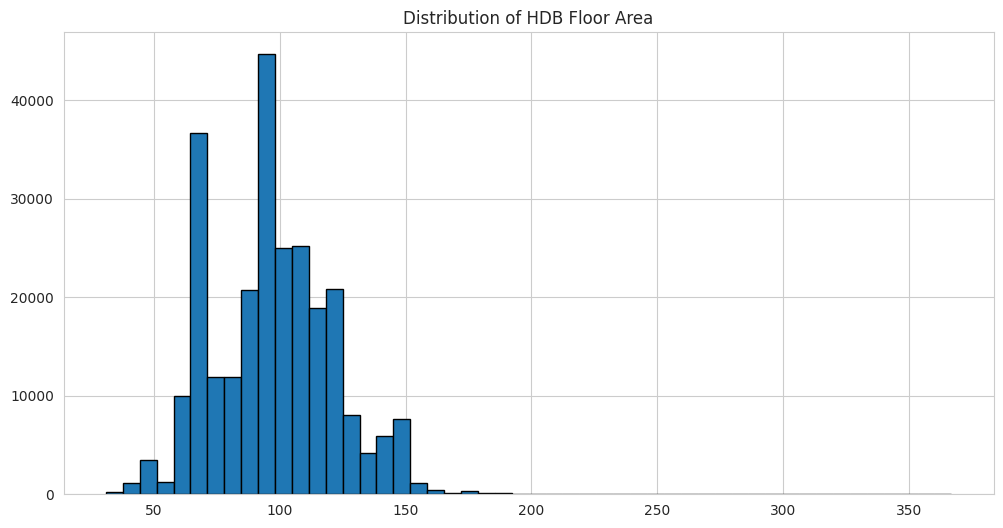

,count
flat_type_model,
EXECUTIVE Apartment,197
EXECUTIVE Maisonette,26
3 ROOM Terrace,15
EXECUTIVE Premium Maisonette,4
EXECUTIVE Adjoined flat,1


In [ ]:
plt.hist(hdb_price['floor_area_sqm'], bins=50, edgecolor='black')
plt.title('Distribution of HDB Floor Area')
plt.show()
display(hdb_price[hdb_price['floor_area_sqm'] > 180]['flat_type_model'].value_counts())

The floor area "outliers" mostly belong to special HDBs that are larger than the standard ones. Hence, they cannot be considered as outliers.

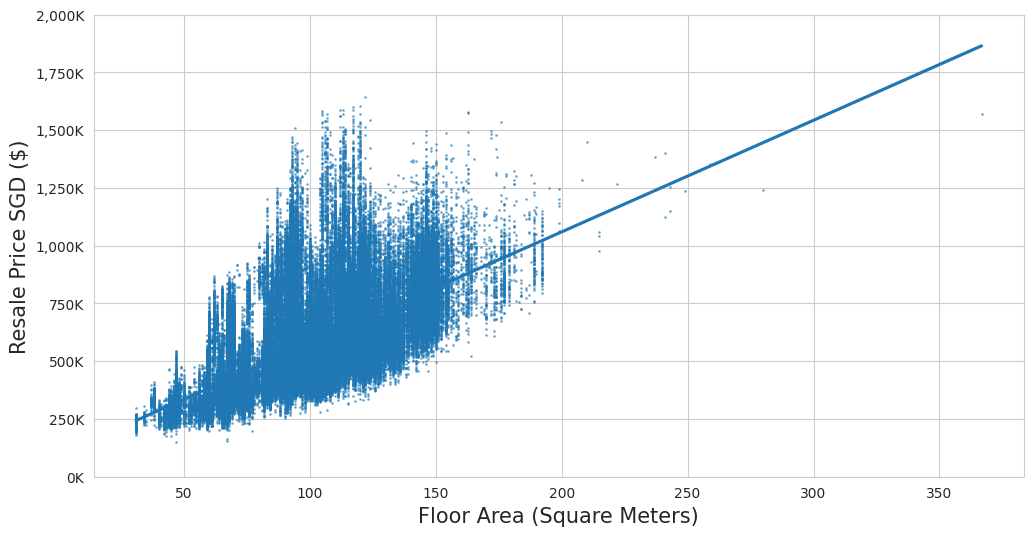

In [ ]:
# Floor Area vs Prices
area = hdb_price[hdb_price['year'].isin([2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025])]
p=sns.regplot(x='floor_area_sqm', y='real_price', data=area, scatter_kws={"s": 1, 'alpha':0.5})
ylabels = ['{:,.0f}'.format(x) + 'K' for x in p.get_yticks()/1000]
p.set_yticks(p.get_yticks()) # Fixes the UserWarning by setting ticks first
p.set_yticklabels(ylabels)
p.set_ylabel('Resale Price SGD ($)', size=15)
p.set_xlabel('Floor Area (Square Meters)', size=15)
plt.show()

#### <font style = 'color:black'> 4. Storey Range Analysis (floor level impact) </font>

---



In [ ]:
# Understand our storey type data with summary statistics, round(2) to show values without scientific notations
storey_stats = hdb_price.groupby('storey_range')['real_price'].agg(['count', 'mean', 'median'])

# Precaution step
# Sort by the first two characters of the storey range (the lower bound)
storey_stats['sort_key'] = storey_stats.index.str[:2].astype(int)

# Sort by that temporary column
storey_stats = storey_stats.sort_values('sort_key')

# Remove the temporary column and round the results
storey_stats = storey_stats.drop(columns='sort_key').round(2)

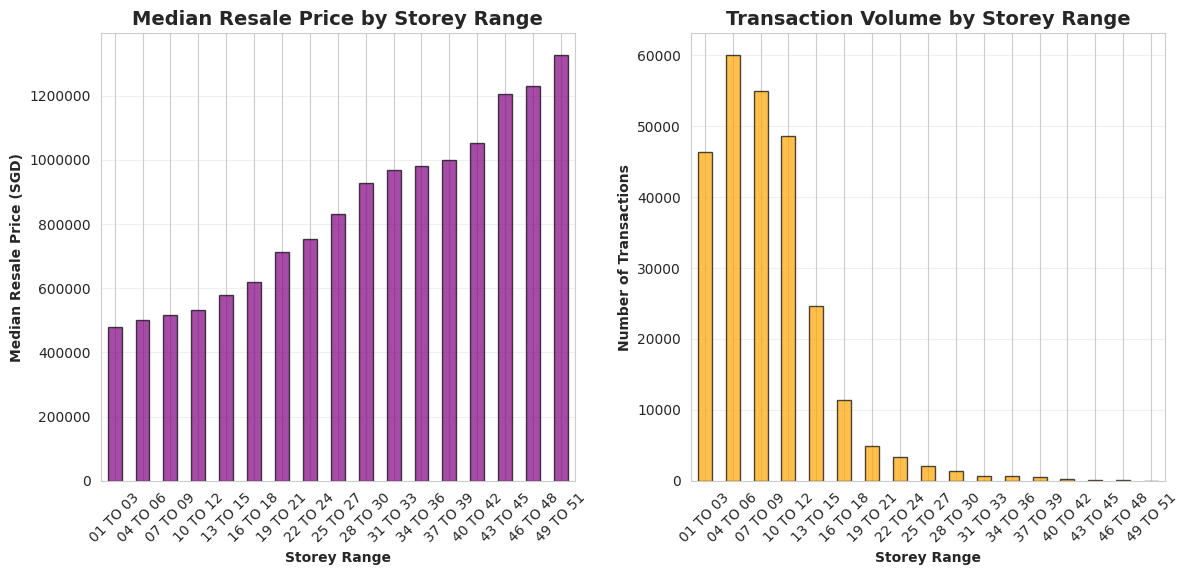

In [ ]:
# Visualise Storey Type
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

## FIRST CHART (Median)
# Bar Chart -- Median Resale Price by Storey Range (Left)
storey_stats['median'].plot(kind='bar', ax=ax[0], color='purple', edgecolor='black', alpha=0.7)

# Show the real value of resale prices, not in scientific notation
ax[0].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[0].set_title('Median Resale Price by Storey Range', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Storey Range', fontweight='bold')
ax[0].set_ylabel('Median Resale Price (SGD)', fontweight='bold')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', alpha=0.3)

## =================================================================================
## SECOND CHART (Count)
# Bar Chart -- Median Resale Price by Storey Range (Right)
storey_stats['count'].plot(kind='bar', ax=ax[1], color='orange', edgecolor='black', alpha=0.7)

# Show the real value of resale prices, not in scientific notation
ax[1].ticklabel_format(style='plain', axis='y')

# Set titles and labels
ax[1].set_title('Transaction Volume by Storey Range', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Storey Range', fontweight='bold')
ax[1].set_ylabel('Number of Transactions', fontweight='bold')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

# Show data values, verify values only (Comment out because not visually appealing)
# ax[0].bar_label(ax[0].containers[0], padding=5, fmt='S$%.0f')
# ax[1].bar_label(ax[1].containers[0], padding=5, fmt='S$%.0f')

# Remove the automatic subtitle
plt.suptitle('')

plt.tight_layout(w_pad=2) # They are too close together, w_pad means width padding adjusted to 2.
plt.show()

What can we understand from these charts?
- **Price increase with floor level (Left chart)**: Flats with lower floors have **lowest median price** around SGD400,000, and prices increase consistently for every higher storey range, peaking at the highest floors with a **median price over SGD$1 million**
- **Transaction volume highest at low-to-mid levels (Right chart)**: Peaks at **04 TO 06** and **07 TO 09**, each with **over 60,000 transactions**. The volume drop significantly for floors above the 12th storey and becomes very low for the highest floors.

Overall, **higher floors have more premium prices**, but majority of the market activity occurs on the **lower-to-mid level floors**

#### <font style = 'color:black'> 5. Town analysis </font>

---




In [ ]:
# Quick analysis: Average real price by town
town_analysis = hdb_price.groupby('town')['real_price'].median().sort_values(ascending=False)
print(town_analysis)

town
BUKIT TIMAH        845705.690
BISHAN             743779.560
QUEENSTOWN         709653.470
BUKIT MERAH        707555.695
CENTRAL AREA       615868.830
PASIR RIS          605994.380
KALLANG/WHAMPOA    604490.500
TAMPINES           578319.550
PUNGGOL            572095.470
SERANGOON          571568.550
SENGKANG           552103.280
MARINE PARADE      541960.720
HOUGANG            520687.075
BUKIT PANJANG      519962.860
SEMBAWANG          518342.400
TOA PAYOH          512835.755
CLEMENTI           512041.810
CHOA CHU KANG      510406.340
JURONG WEST        495154.560
BUKIT BATOK        492166.350
WOODLANDS          489024.670
GEYLANG            484416.950
JURONG EAST        477162.080
BEDOK              460696.230
YISHUN             457372.545
ANG MO KIO         437041.230
Name: real_price, dtype: float64


/tmp/ipykernel_5866/3460529451.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hdb_price, x='real_price', y='town', order=town_order, estimator='median', errorbar=None, palette='viridis')


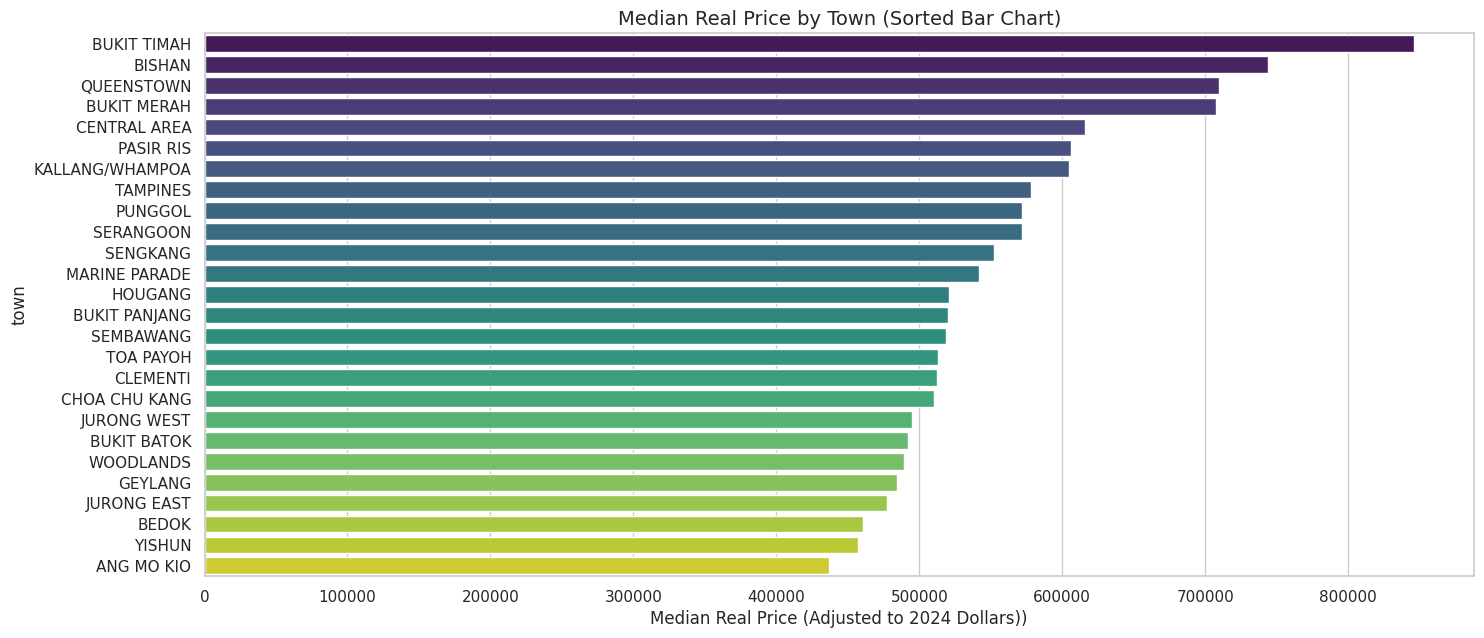

In [ ]:
# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 18))

# --- BAR CHART (Comparing Towns by Median) ---
plt.subplot(3, 1, 3)
# Calculate median per town and sort it
town_order = hdb_price.groupby('town')['real_price'].median().sort_values(ascending=False).index
sns.barplot(data=hdb_price, x='real_price', y='town', order=town_order, estimator='median', errorbar=None, palette='viridis')
plt.title('Median Real Price by Town (Sorted Bar Chart)', fontsize=14)
plt.xlabel('Median Real Price (Adjusted to 2024 Dollars))')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5866/64396043.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


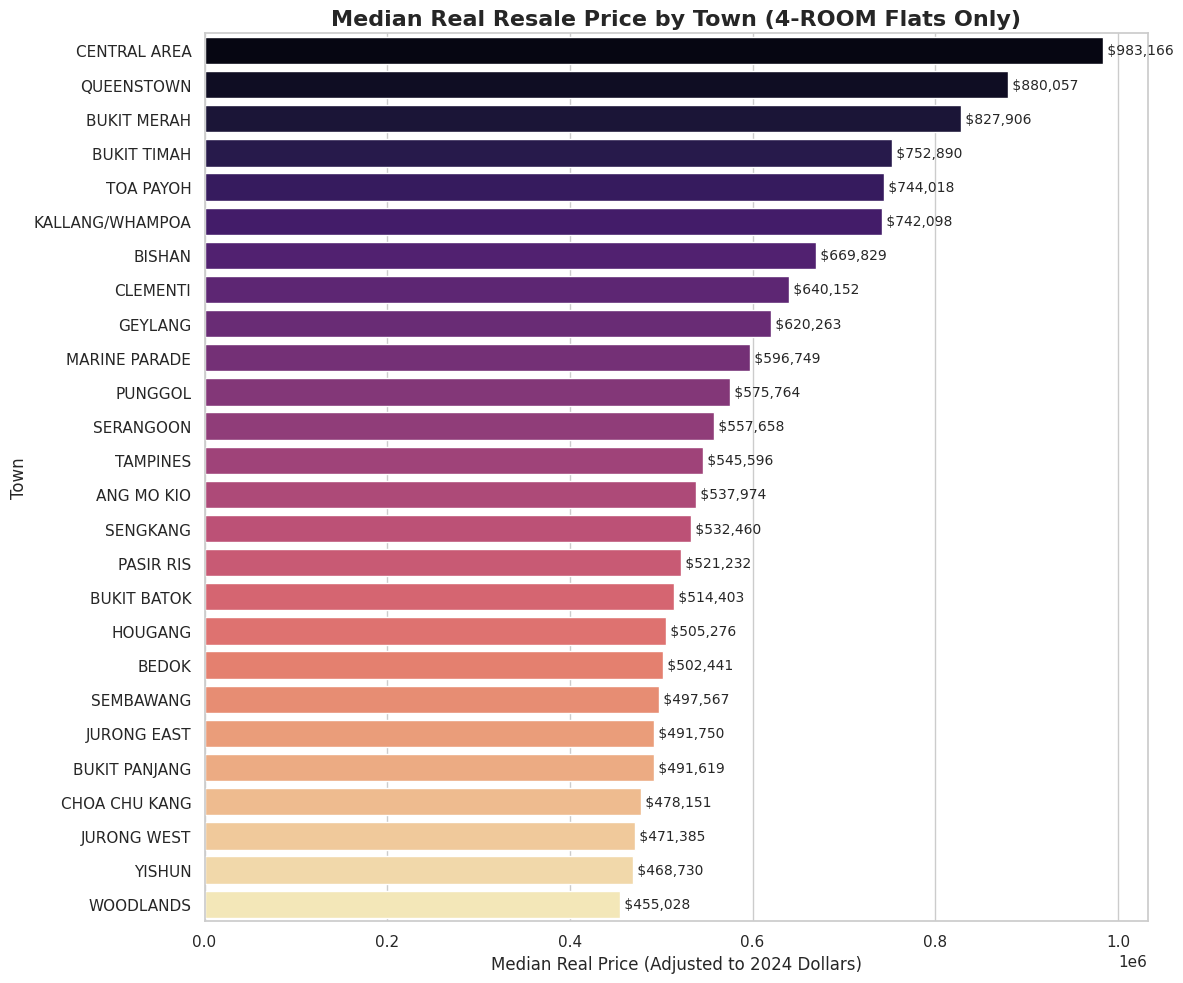

In [ ]:
# focusing on 4 room flats as 4 rooms have the highest transaction
# Filter for 4-Room flats
df_4room= hdb_price[(hdb_price['flat_type'] == '4 ROOM')]

# Calculate Medians and sort the towns
# This ensures the chart is easy to read from most to least expensive
town_order = df_4room.groupby('town')['real_price'].median().sort_values(ascending=False).index

# Create the Bar Chart
plt.figure(figsize=(12, 10))
sns.barplot(
    data=df_4room,
    x='real_price',
    y='town',
    order=town_order,
    estimator='median',
    errorbar=None,
    palette='magma'
)

# 6. Add labels and formatting
plt.title('Median Real Resale Price by Town (4-ROOM Flats Only)', fontsize=16, fontweight='bold')
plt.xlabel('Median Real Price (Adjusted to 2024 Dollars)', fontsize=12)
plt.ylabel('Town', fontsize=12)

# Add value labels to the end of each bar for clarity
for i, town in enumerate(town_order):
    median_val = df_4room[df_4room['town'] == town]['real_price'].median()
    plt.text(median_val, i, f' ${median_val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### <font style = 'color:black'> 6. Lease commence date Analysis </font>

---


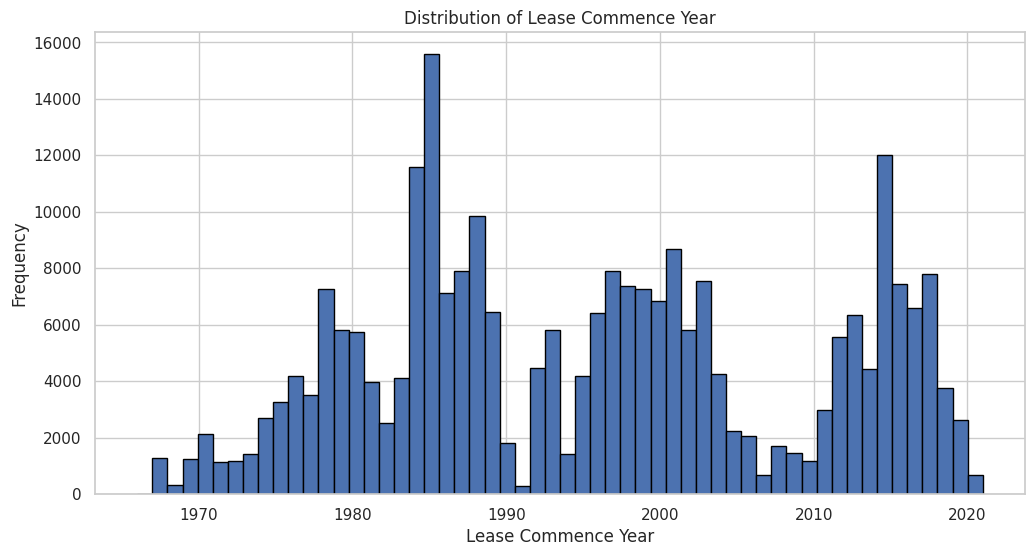

In [ ]:
min_year = hdb_price['lease_commence_date'].dt.year.min()
max_year = hdb_price['lease_commence_date'].dt.year.max()
bins = max_year - min_year + 1 # Calculate the number of bins (one for each year)

plt.hist(hdb_price['lease_commence_date'].dt.year, bins=bins, edgecolor='black')
plt.title('Distribution of Lease Commence Year')
plt.xlabel('Lease Commence Year')
plt.ylabel('Frequency')
plt.show()

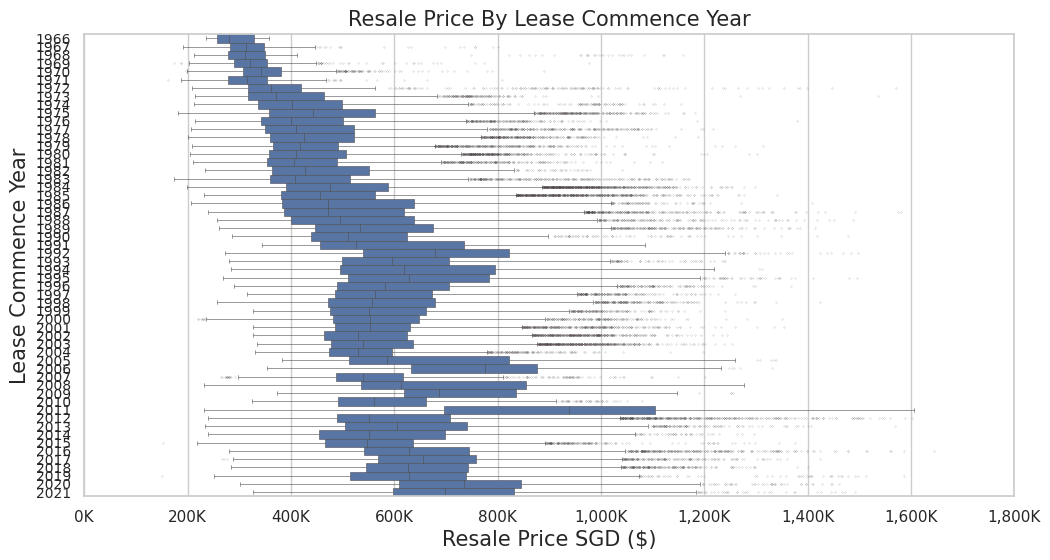

In [ ]:
# Create a sorted list of unique dates
sorted_dates = sorted(hdb_price['lease_commence_date'].unique())

p = sns.boxplot(
    y='lease_commence_date',
    x='real_price',
    data=hdb_price,
    order=sorted_dates,  # This forces the chronological order
    width=1,
    orient='h', flierprops = dict(markerfacecolor = 'red', markersize = 0.1, linestyle='none'), linewidth=0.4)

# Clean up the Y-axis (Show only the Year)
# This takes the full date string and splits it to keep only the first 4 characters
y_labels = [str(label.get_text())[:4] for label in p.get_yticklabels()]
p.set_yticks(p.get_yticks()) # Fixes the UserWarning by setting ticks first
p.set_yticklabels(y_labels, size=10)

p.set_xlabel('Resale Price SGD ($)', size=15), p.set_ylabel('Lease Commence Year', size=15)
xlabels = ['{:,.0f}'.format(x) + 'K' for x in p.get_xticks()/1000]
p.set_xticks(p.get_xticks())
p.set_xticklabels(xlabels)
p.set_title('Resale Price By Lease Commence Year', size=15)
plt.show()

#### <font style = 'color:black'> 7. Distance to nearest amenities Analysis</font>

---

In [ ]:

# # 1. Filter and ensure chronological/logical order if needed
# yr = hdb_price[hdb_price['year'].isin(range(2015, 2026))].copy()

# # 2. Create the pairplot
# p = sns.pairplot(
#     yr,
#     x_vars=["school_dist_m", "priority_school_dist_m", "hawker_dist_m", "park_dist_m",
#             "mall_dist_m", "MRT_dist_m", "MRT_interchange_dist_m", "bus_stop_dist_m"],
#     y_vars=["real_price"],
#     height=3,
#     aspect=1,
#     kind="reg",
#     plot_kws=dict(scatter_kws=dict(s=40, alpha=0.5))
# )

# axes = p.axes
# x_vars = ["school_dist_m", "priority_school_dist_m", "hawker_dist_m", "park_dist_m",
#           "mall_dist_m", "MRT_dist_m", "MRT_interchange_dist_m", "bus_stop_dist_m"]

# x_label_names = [
#     'Dist. School', 'Dist. Top Primary', 'Dist. Hawker', 'Dist. Park',
#     'Dist. Mall', 'Dist. MRT', 'Dist. MRT Interchange', 'Dist. Bus Stop'
# ]

# # 3. Loop through each subplot to fix labels and add Correlation (r)
# for i, var in enumerate(x_vars):
#     # Calculate Pearson correlation coefficient
#     corr, _ = stats.pearsonr(yr[var], yr['real_price'])

#     # Set the xlabel and include the Correlation value in the title
#     axes[0, i].set_xlabel(f"{x_label_names[i]} (m)", size=10)
#     axes[0, i].set_title(f"r = {corr:.2f}", size=12, fontweight='bold')

#     # Fix the Y-axis labels for the first plot only (since they share y)
#     if i == 0:
#         yticks = axes[0, 0].get_yticks()
#         axes[0, 0].set_yticks(yticks) # FixedLocator fix
#         ylabels = ['{:,.0f}K'.format(x/1000) for x in yticks]
#         axes[0, 0].set_yticklabels(ylabels)
#         axes[0, 0].set_ylabel('Resale Price SGD ($)', size=12)

# # 4. Final Formatting
# plt.suptitle('Resale Price vs. Distance to Amenities (with Correlation Coefficients)', y=1.05, size=16)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

## <font style = 'color:black'>003c - Exploratory Data Analysis (EDA) Phase 3</font>
---
We dive deeper into the trends.

  - Price trends over time (Detailed)

  For more EDA, see power BI



**Price trends over time (Detailed)**


**To see price changes by Town from Jan 2015 to Jan 2026**


---


**Standard Percentage Change Formula (spcf)**

The formula tells you how much something **grew** or **shrank** compared to where it started.

Source: https://www.wallstreetprep.com/knowledge/percent-change/

In [ ]:
# Calculate median resale price per planning area for every transaction year (use resale price here to see price trends)
yearly_medians = hdb_price.groupby(['town', 'year'])['resale_price'].median()

# Count total transactions per planning area to ensure data reliability
counts = hdb_price.groupby('town').size()

# Extract the earliest and latest available median price for each area
price_trends = yearly_medians.groupby('town').agg(
    start_price='first',
    end_price='last'
)

# Use Standard percentage change formula: ((New - Old) / Old) * 100
price_trends['spcf'] = ((price_trends['end_price'] - price_trends['start_price']) / price_trends['start_price'] * 100).round(2)

# Calculate a dynamic threshold for reliable data points based on years spanned
total_years_span = (hdb_price['year'].max() - hdb_price['year'].min()) + 1
required_threshold = total_years_span * 3
price_trends = price_trends[counts >= required_threshold].reset_index() # .reset_index converts index labels back into regular data columns.

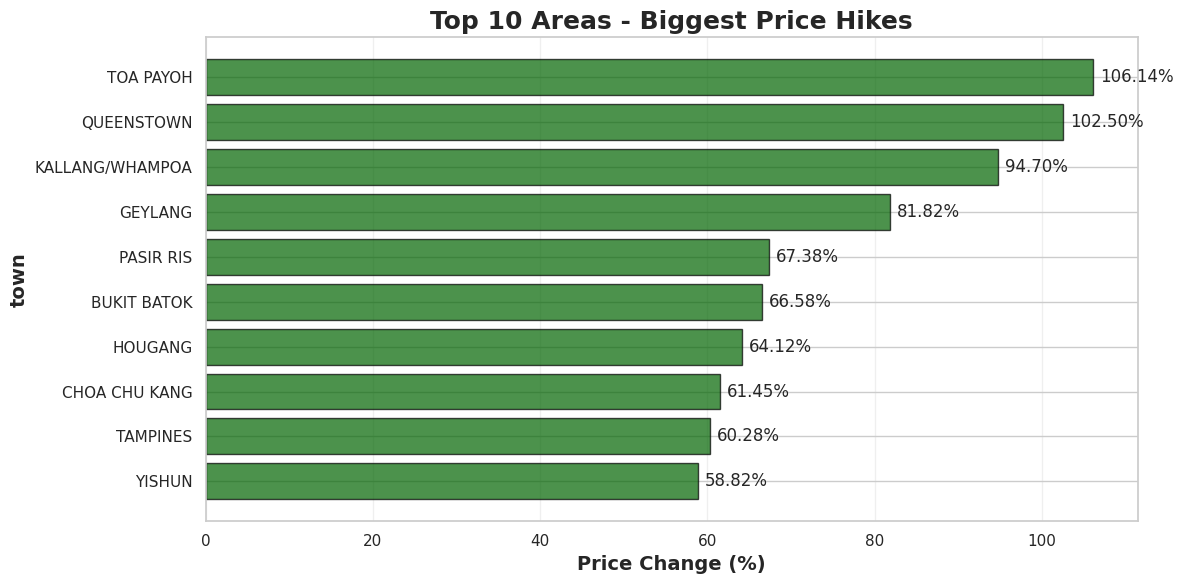

In [ ]:
plt.figure(figsize=(12,6))

# Top gainers
top_gainers = price_trends.sort_values(by='spcf', ascending=False).head(10)
barh = plt.barh(top_gainers['town'], top_gainers['spcf'],
               color='darkgreen', edgecolor='black', alpha=0.7)

plt.yticks(range(len(top_gainers['spcf'])), labels=top_gainers['town'])
plt.ylabel('town', fontsize=14, fontweight='bold')
plt.xlabel('Price Change (%)', fontsize=14, fontweight='bold')
plt.title('Top 10 Areas - Biggest Price Hikes', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Show data values
plt.bar_label(barh, padding=5, fmt='%.2f%%')

plt.tight_layout()
plt.show()

**What can we understand from this chart?**
- __Significant Gains__: The top 10 Towns all show substantial gains of over 50%. with Toa Payoh and Queenstown both having more than 100% of price hikes


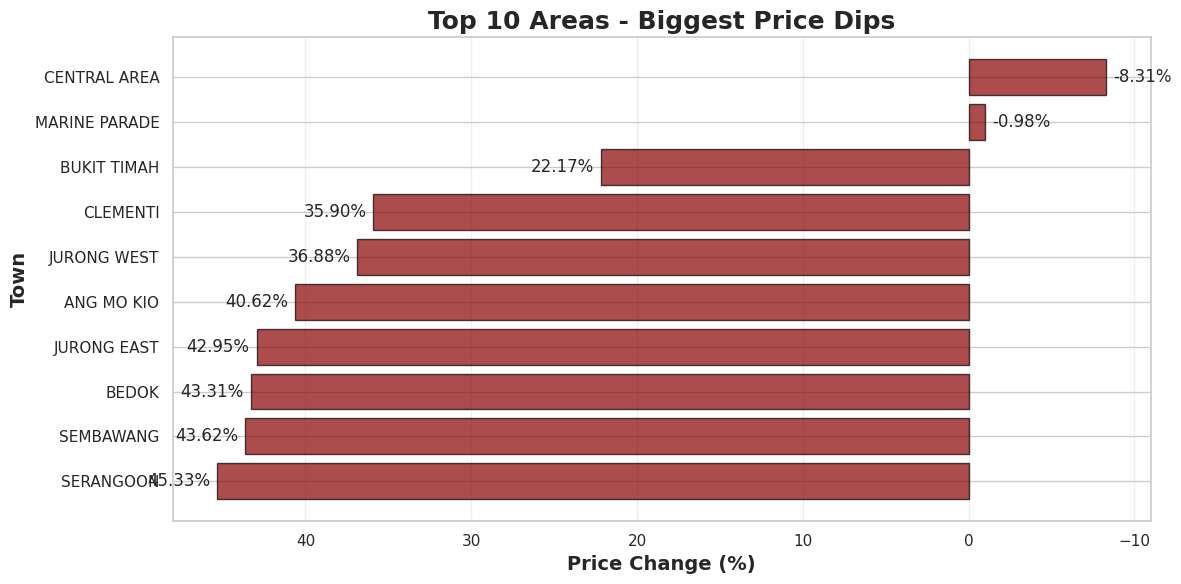

In [ ]:
plt.figure(figsize=(12,6))

# Top losers
top_losers = price_trends.sort_values(by='spcf', ascending=True).head(10)
barh = plt.barh(top_losers['town'], top_losers['spcf'],
               color='darkred', edgecolor='black', alpha=0.7)

plt.yticks(range(len(top_losers['spcf'])), labels=top_losers['town'])
plt.ylabel('Town', fontsize=14, fontweight='bold')
plt.xlabel('Price Change (%)', fontsize=14, fontweight='bold')
plt.title('Top 10 Areas - Biggest Price Dips', fontsize=18, fontweight='bold')
plt.gca().invert_xaxis() # Change negative to right side of the chart
plt.gca().invert_yaxis() # Sort by descending order
plt.grid(axis='x', alpha=0.3)

# Show data values
plt.bar_label(barh, padding=5, fmt='%.2f%%')

plt.tight_layout()
plt.show()

**What can we understand from this chart?**


*   Only Central area and Marine parade have losses and the price dip is not significant at -8.31% and -0.98%



## <font style = 'color:black'>004 - Feature Importance Analysis</font>
---
We identify which features have the strongest correlation to resale price, using __Linear Regression__ for our model in this analysis.

1. Correlation Matrix for numerical features with Correlation Heatmap
2. Encode Categorical Variables
3. Select features for modelling

4.   Linear Regression Set Up
5.  Linear Regression Feature Importance (Coefficient)
    >- Horizontal Bar Chart


In [ ]:

# Check current
print(f'hdb_price.csv shape: {hdb_price.shape}')
print(f'hdb_price.csv nulls:', hdb_price.isnull().sum().sum())
print(f'hdb_price.csv data types:\n{hdb_price.dtypes}\n')

hdb_price.csv shape: (260019, 46)
hdb_price.csv nulls: 0
hdb_price.csv data types:
month                               int32
year                                int32
sale_date                  datetime64[ns]
town                               object
flat_type                          object
block                              object
street_name                        object
storey_range                       object
floor_area_sqm                    float64
flat_model                         object
lease_commence_date        datetime64[ns]
remaining_lease                    object
resale_price                      float64
address                            object
postal_code                        object
latitude                          float64
longitude                         float64
num_bus_stop_1km                  float64
num_hawker_1km                    float64
num_park_1km                      float64
num_mall_1km                      float64
Nearest school                     

**1. Correlation Matrix for numerical features with Correlation Heatmap**


---



In [ ]:
# Select only numerical basic features, used 15 features.
numerical_basic_features = [
    'lease_commence_date', 'month', 'year','sale_date', 'mid', 'floor_area_sqm','resale_price_per_sqm',
    'real_price_per_sqm', 'hdb_age', 'latitude', 'longitude',
    'cpi',
    'resale_price' # including target variable
]

corr_matrix_basic = hdb_price[numerical_basic_features].corr() # This is what we are going to use for plot

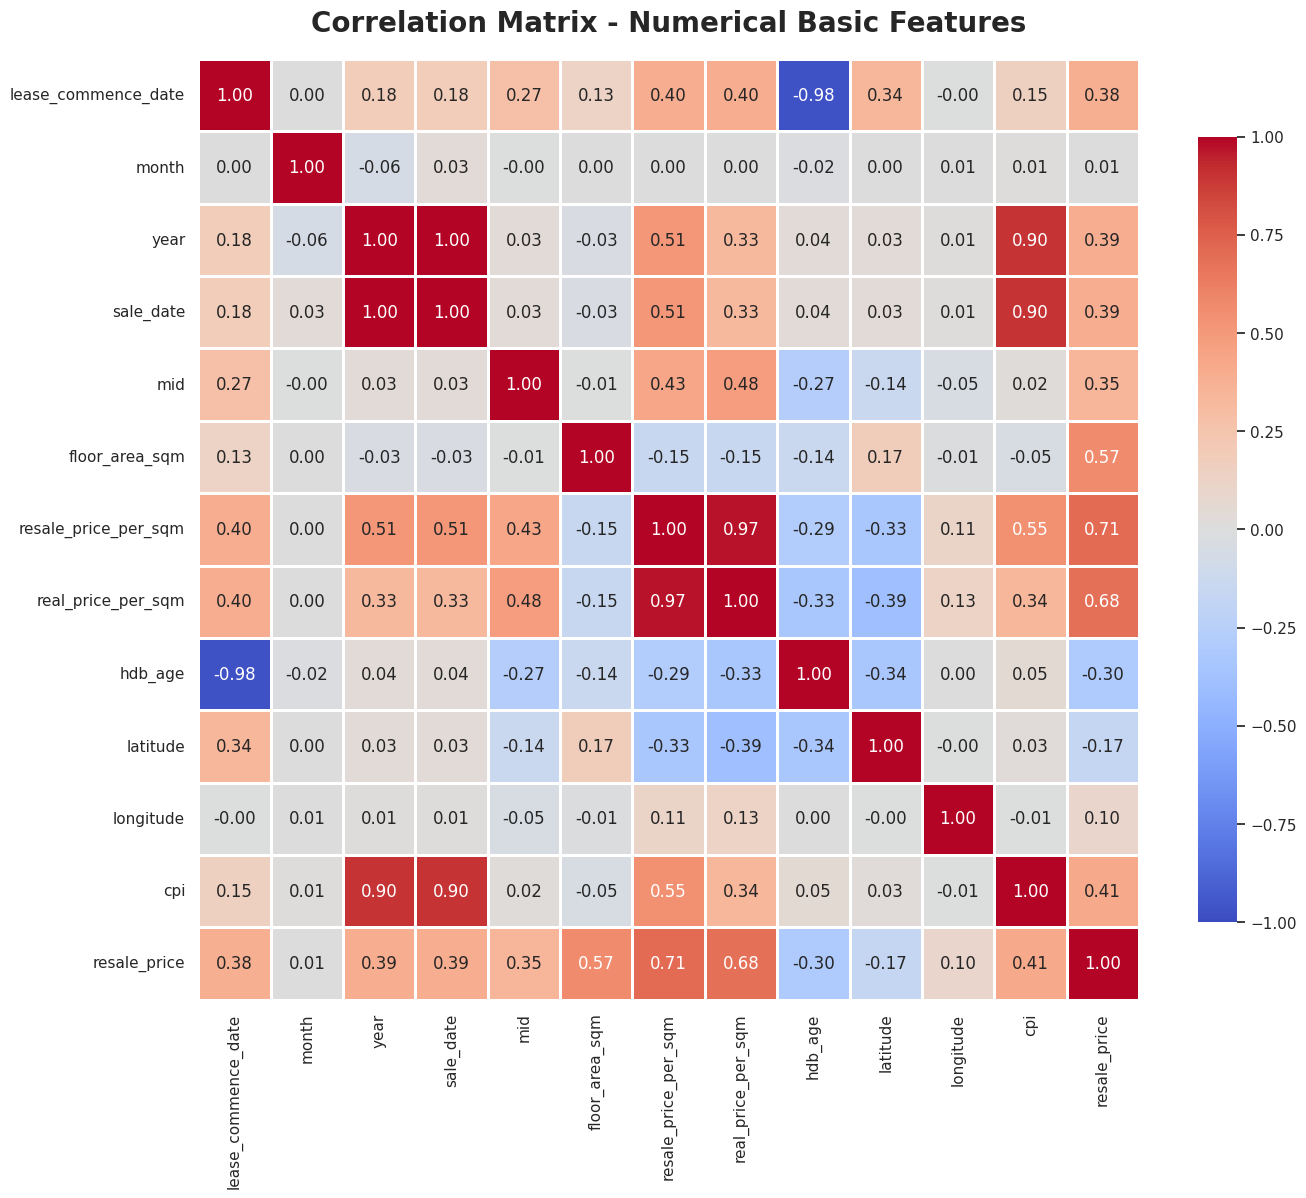

In [ ]:
# Visualise Correlation Matrix with Correlation Heatmap
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix_basic, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Basic Features', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**What can we understand from the Basic Correlation HeatMap?**

In relation to **resale price (target variable**) :
1. Strongest Positive Correlation   
    - __resale_price_per_sqm (0.71)__
   - __real_price_per_sqm (0.68)__  
   - __floor_area_sqft (0.57)__ means bigger flat, higher price
    - __cpi (0.41)__ means more hgher the inflation rate, higher price  
   - __month & year (0.39)__ means more recent sold flats, higher price
   - __lease_commence_date (0.38)__ means newer flats, higher price
   - __mid (storey level) (0.35)__ means higher floor, higher price<br>
2. Strongest Negative Correlation
    - __hdb_age (-0.30)__ means older flat, lower price
    - __latitude (-0.17)__ means southern areas more expensive

In [ ]:
# Select only numerical amenities features, used 15 features.
numerical_amenities_features = [
    'mall_dist_m', 'num_mall_1km', 'park_dist_m', 'num_park_1km', 'hawker_dist_m', 'num_hawker_1km',
    'MRT_dist_m','num_mrt_1km', 'MRT_interchange_dist_m','num_mrt_interchange_1km',
    'bus_stop_dist_m', 'num_bus_stop_1km',
    'school_dist_m', 'num_school_1km', 'num_school_2km','priority_school_dist_m','num_priority_sch_1km','num_priority_sch_2km',
    'resale_price' # including target variable
]

corr_matrix_amenities = hdb_price[numerical_amenities_features].corr() # This is what we are going to use for plot

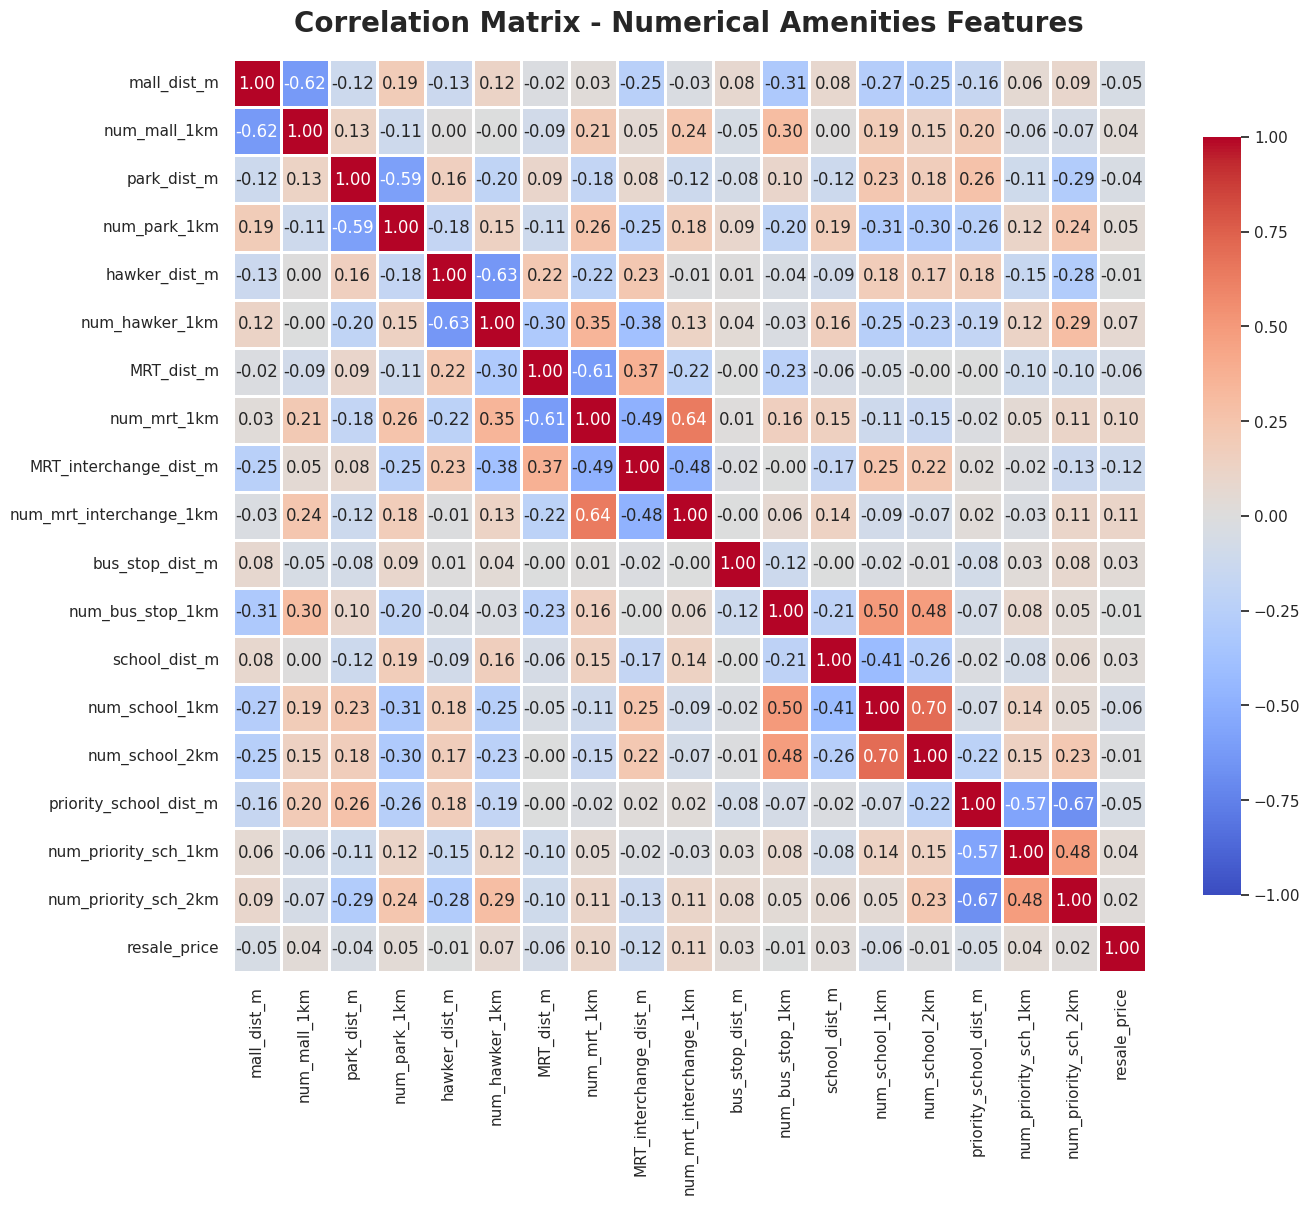

In [ ]:
# Visualise Correlation Matrix for amenities with Correlation Heatmap
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix_amenities, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Amenities Features', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**What can we understand from the Amenities Correlation HeatMap?**

Most individual amenities have a very weak direct correlation with resale_price. Almost all amenities values are between -0.12 and 0.11.

This suggests that a single factor—like being near a mall or a school—doesn't dictate the price on its own. Instead, the price is likely driven by a complex combination of these factors, or by variables not shown here (like flat size, remaining lease, or specific floor level).

In relation to **resale price (target variable**) :
1. Strongest Positive Correlation


    *   **Number of MRT Stations (+0.10)**: The strongest positive correlation in this set. Having more MRT options within 1km is the most consistent "value-add" among the numerical amenities shown.
    *   **Number of MRT Interchanges (+0.11)**: Similar to the above, proximity to major transit hubs (Interchanges) has a slight positive pull on the price.
    *   **Number of Hawker Centres (+0.07)**: A minor positive correlation, suggesting that "foodie" convenience adds some value.<br>

2. Strongest Negative Correlation
    * **MRT Interchange Distance (-0.12)**: This is the strongest "distance" relationship. The closer you are to an interchange, the higher the resale price tends to be.
    * **Mall Distance (-0.05)**: A very slight negative correlation; being closer to a mall has a tiny upward pressure on price, but it's much weaker than the MRT effect.
3. The "Surprise" Neutral correlation
    * **Priority Schools (-0.05 to +0.04)**: Whether the flat are near a priority school or have many nearby seems to have almost no linear impact on the price across the whole dataset.
    * **Parks (-0.04 to +0.05)**: Being near a park or having many parks nearby shows a negligible relationship with the resale price here.

Since these individual correlations are all quite low (below 0.2), it tells us that Linear Regression on just one of these features won't be very accurate. We likely need a model that combines them (like Random Forest) to capture the "lifestyle value" of a location.

**2. Encode Categorical Variables**


---



**Phase 1: General Cleanup (For Linear regression & Random forest)**
Models can handle datetime or plain text. I need to clean these up before applying model-specific encoding.

Datetime columns (sale_date, lease_commence_date): Extract the numeric components. For example, extract the month (1-12) and year from sale_date. I can likely drop lease_commence_date entirely since I already have hdb_age.

Messy text (remaining_lease): This usually looks like "90 years 02 months". I need to parse this into a single float64 representing total years (e.g., 90.16).

Redundant categoricals (storey_range, address, postal_code): Drop storey_range because I already have the numeric mid (mid-point of the floor). Drop address and postal_code because they have extreme cardinality (too many unique values) and I already have latitude, longitude, and town to represent location.

**Drop "Data Leakage" Columns**

---

Before doing any encoding, I will remove these columns. They contain the answer (the price) inside them.

  * *resale_price_per_sqm*

  * *real_price*

  * *real_price_per_sqm*


---


**Part 1: Pre-Encoding Cleanup (Both Models) & train test split**

Both **Linear Regression (LR)** and **Random Forest (RF)** need these fixes before they can process the data.

  1.  **Parse remaining_lease (Object to Float):**
  
      Currently "85 years 03 months".
      
      **Action:** Convert to a decimal number (e.g., 85.25).
   
  2. **Handle Dates:**
        * month (int), year (int), and sale_date (datetime).
        * **Action:** Drop *sale_date* and *lease_commence_date*. I already have *year*, *month*, and *hdb_age*.
  3. **Redundancy Checks:**
        * *storey_range*: Drop this as I already have mid (which is the numerical midpoint of the storey range). Models prefer numbers over categories like "10-12".
        * *flat_type* & *flat_model*: Drop these, It is just a combination of *flat_type_model*.
        * *address* / *postal_code*: Drop these, I will be using *latitude*, *longitude*, and *town*.
  4. **Train Test Split**

In [ ]:
#drop columns that we don't need
columns_to_drop = [
    'resale_price_per_sqm',
    'real_price',
    'real_price_per_sqm',
    'sale_date',
    'lease_commence_date',
    'storey_range',
    'flat_type',
    'flat_model',
    'address',
    'postal_code'
]

# Drop the columns (axis=1 means columns, inplace=True modifies the original dataframe)
hdb_price.drop(columns=columns_to_drop, inplace=True)

# Quick check to verify they are gone and look at the new shape
print(f"Remaining columns: {hdb_price.shape[1]}")
print(hdb_price.columns)

Remaining columns: 36
Index(['month', 'year', 'town', 'block', 'street_name', 'floor_area_sqm',
       'remaining_lease', 'resale_price', 'latitude', 'longitude',
       'num_bus_stop_1km', 'num_hawker_1km', 'num_park_1km', 'num_mall_1km',
       'Nearest school', 'num_school_1km', 'num_school_2km',
       'Nearest priority school', 'num_priority_sch_1km',
       'num_priority_sch_2km', 'Nearest MRT Station', 'num_mrt_1km',
       'Nearest MRT interchange', 'num_mrt_interchange_1km', 'cpi',
       'bus_stop_dist_m', 'hawker_dist_m', 'park_dist_m', 'mall_dist_m',
       'MRT_interchange_dist_m', 'priority_school_dist_m', 'MRT_dist_m',
       'school_dist_m', 'hdb_age', 'mid', 'flat_type_model'],
      dtype='object')


In [ ]:
# Parse remaining_lease (Object to Float)

# 1. Convert everything to lowercase strings first to avoid capital letter issues
lease_str = hdb_price['remaining_lease'].astype(str).str.lower()

# 2. Extract the FIRST number found in the string as 'years'
# Using r'(^\d+)' just looks for digits at the very start of the text
years = lease_str.str.extract(r'(^\d+)')[0].astype(float)

# 3. Extract the number right before the word 'month'
months = lease_str.str.extract(r'(\d+)\s*month')[0].astype(float).fillna(0)

# 4. Do the math and round it
hdb_price['remaining_lease'] = (years + (months / 12)).round(2)

# Verify!
print(hdb_price[['remaining_lease']].head())

   remaining_lease
0             70.0
1             65.0
2             64.0
3             63.0
4             64.0


In [ ]:
print(hdb_price.head())
print(hdb_price.tail())

   month  year        town block        street_name  floor_area_sqm  \
0      1  2015  ANG MO KIO   174   ANG MO KIO AVE 4            60.0   
1      1  2015  ANG MO KIO   541  ANG MO KIO AVE 10            68.0   
2      1  2015  ANG MO KIO   163   ANG MO KIO AVE 4            69.0   
3      1  2015  ANG MO KIO   446  ANG MO KIO AVE 10            68.0   
4      1  2015  ANG MO KIO   557  ANG MO KIO AVE 10            68.0   

   remaining_lease  resale_price  latitude   longitude  ...  hawker_dist_m  \
0             70.0      255000.0  1.375097  103.837619  ...         184.32   
1             65.0      275000.0  1.373922  103.855621  ...         181.90   
2             64.0      285000.0  1.373549  103.838176  ...         155.57   
3             63.0      290000.0  1.367761  103.855357  ...         124.09   
4             64.0      290000.0  1.371626  103.857736  ...         386.06   

   park_dist_m  mall_dist_m  MRT_interchange_dist_m priority_school_dist_m  \
0       338.00       990.4

**Prep: Train test split the hdb_price Dataset**

---

In [ ]:
# Separate Features (X) and Target (y)
# We drop 'resale_price' from X, and make it our y
X = hdb_price.drop(columns=['resale_price'])
y = hdb_price['resale_price']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Split the data (same test_size and random_state as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Features shape: (260019, 35)
Target shape: (260019,)
Training features shape: (208015, 35)
Testing features shape: (52004, 35)
Train set: 208015 samples
Test set: 52004 samples


In [ ]:
# Save to CSV
X_train.to_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/X_train.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/X_test.csv', index=False)
X_train.to_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/y_test.csv', index=False)

**Part 2: Encoding Strategy**

Here is the breakdown of which columns to encode and how to do it for each model.

**A. Linear Regression (The "Math" Approach)**

Linear regression fails if features are not on the same scale or if it treats categories as ranked numbers

(e.g., assuming "Bedok" > "Ang Mo Kio").

**Numeric features**, including *floor_area_sqm, hdb_age, lat, long, mid, cpi,* and various distance or numeric indicators require **Standard Scaling**. This is necessary because **Linear Regression** weights are sensitive to magnitude; for instance, large distances in meters could overpower small decimals like the cpi if not properly scaled.

**Low-Cardinality Categorical features** like *town, flat_type, and flat_model,* the strategy is **One-Hot Encoding**. This converts a category like "Bedok" into a binary column (town_Bedok as 1 or 0), which prevents the model from assigning false mathematical rankings.

**High-Cardinality Categorical features** such as *Nearest MRT Station, Nearest school, and Nearest priority school,* the strategy is to either **Drop or Target Encode them**. Since **One-Hot Encoding** these would create over 100 columns and ruin model performance, I can safely drop the specific names of stations or schools since I already have distance-based features like *MRT_dist_m* available.


In [ ]:
# 1. BRANCH THE DATAFRAMES
# (for hdb_price which is our currently cleaned and scaled dataset)

X_train_lr = X_train.copy()
X_test_lr = X_test.copy()
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_lr = y_train.copy()
y_test_lr = y_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

In [ ]:

# 2. PREPARE DATAFRAME FOR LINEAR REGRESSION (hdb_price_lr)
# Strategy: One-Hot Encode low cardinality, drop high cardinality names

cols_to_ohe = ['town', 'flat_type_model']
X_train_lr = pd.get_dummies(X_train_lr, columns=cols_to_ohe, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, columns=cols_to_ohe, drop_first=True)

# ALIGN THE COLUMNS
# This ensures X_test_lr has the exact same columns as X_train_lr
# It adds missing columns with 0s and drops any 'new' columns only in test
X_test_lr = X_test_lr.reindex(columns=X_train_lr.columns, fill_value=0)

high_card_cols_to_drop = [
    'Nearest school',
    'Nearest priority school',
    'Nearest MRT Station',
    'Nearest MRT interchange',
    'block', # Added 'block' to drop
    'street_name' # Added 'street_name' to drop
]
X_train_lr .drop(columns=high_card_cols_to_drop, inplace=True, errors='ignore')
X_test_lr.drop(columns=high_card_cols_to_drop, inplace=True, errors='ignore')

print(f"Linear Regression X_train dataset shape: {X_train_lr.shape}")
print(f"Linear Regression X_test dataset shape: {X_test_lr.shape}")



Linear Regression X_train dataset shape: (208015, 95)
Linear Regression X_test dataset shape: (52004, 95)


In [ ]:
# Check current data types
print(f'X_train shape: {X_train_lr.shape}')
print(f'X_test shape: {X_test_lr.shape}')
print(f'X_train nulls:', X_train_lr.isnull().sum().sum())
print(f'X_test nulls:', X_test_lr.isnull().sum().sum())
print(f'X_train data types:\n{X_train_lr.dtypes}\n')
print(f'X_test data types:\n{X_test_lr.dtypes}\n')


X_train shape: (208015, 95)
X_test shape: (52004, 95)
X_train nulls: 0
X_test nulls: 0
X_train data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       float64
remaining_lease                                      float64
latitude                                             float64
                                                      ...   
flat_type_model_EXECUTIVE Apartment                     bool
flat_type_model_EXECUTIVE Maisonette                    bool
flat_type_model_EXECUTIVE Premium Apartment             bool
flat_type_model_EXECUTIVE Premium Maisonette            bool
flat_type_model_MULTI-GENERATION Multi Generation       bool
Length: 95, dtype: object

X_test data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       f

In [ ]:
# Find all columns that are currently boolean
bool_cols = X_train_lr.select_dtypes(include='bool').columns
bool_cols = X_test_lr.select_dtypes(include='bool').columns

# Convert them to integers (True becomes 1, False becomes 0)
X_train_lr[bool_cols] = X_train_lr[bool_cols].astype(int)
X_test_lr[bool_cols] = X_test_lr[bool_cols].astype(int)

# Check the dtypes to verify!
print(f'Linear regression data types:\n{X_train_lr.dtypes}\n')
print(f'Linear regression data types:\n{X_test_lr.dtypes}\n')

Linear regression data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       float64
remaining_lease                                      float64
latitude                                             float64
                                                      ...   
flat_type_model_EXECUTIVE Apartment                    int64
flat_type_model_EXECUTIVE Maisonette                   int64
flat_type_model_EXECUTIVE Premium Apartment            int64
flat_type_model_EXECUTIVE Premium Maisonette           int64
flat_type_model_MULTI-GENERATION Multi Generation      int64
Length: 95, dtype: object

Linear regression data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       float64
remaining_lease                                      float6

In [ ]:
#Encoding for Linear Regression
#Standard scaling

#1. Define the explicitly named columns
explicit_cols = ['floor_area_sqm', 'hdb_age','remaining_lease', 'latitude', 'longitude', 'mid', 'cpi']

# 2. Automatically find columns
num_cols = [col for col in hdb_price.columns if col.startswith('num_')]
dist_cols = [col for col in hdb_price.columns if col.endswith('_dist_m')]

# Combine them all into one list (using set to ensure there are no duplicates)
cols_to_scale = list(set(explicit_cols + num_cols + dist_cols))

# 3. Initialize the StandardScaler
scaler = StandardScaler()

# 4. Fit & Transform the selected columns, overwriting them in the dataframe
X_train_lr[cols_to_scale] = scaler.fit_transform(X_train_lr[cols_to_scale])
X_test_lr[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Quick check to see the newly scaled values
print(X_train_lr[cols_to_scale].head())
print(X_test_lr[cols_to_scale].head())
print(f'X_train_lr data types:\n{X_train_lr[cols_to_scale].dtypes}\n')
print(f'X_test_lr data types:\n{X_test_lr[cols_to_scale].dtypes}\n')

        num_park_1km  num_bus_stop_1km  park_dist_m       mid  \
101727      0.154984         -1.408821    -0.932250 -0.629093   
29002       0.154984         -0.388366    -0.171613 -0.117606   
206716     -0.566552         -0.303328    -0.859290  1.416854   
65414       0.154984          0.547052    -0.707215  0.393880   
55084       0.515751         -1.068669    -1.074164 -0.629093   

        MRT_interchange_dist_m  num_hawker_1km  remaining_lease  \
101727               -1.298700        0.261486        -1.373039   
29002                -0.827381        1.533750        -0.884076   
206716               -0.490338        1.533750         1.421658   
65414                -0.489894        2.169882        -1.052859   
55084                -0.463054        1.533750        -0.582005   

        num_school_2km  num_mrt_1km  num_mall_1km  ...  mall_dist_m  \
101727       -1.357272    -0.133701     -1.282288  ...     2.918649   
29002         0.680246    -0.133701     -0.543919  ...     0.288

In [ ]:
# Check current data types
print(f'X_train shape: {X_train_lr.shape}')
print(f'X_test shape: {X_test_lr.shape}')
print(f'X_train nulls:', X_train_lr.isnull().sum().sum())
print(f'X_test nulls:', X_test_lr.isnull().sum().sum())
print(f'X_train data types:\n{X_train_lr.dtypes}\n')
print(f'X_test data types:\n{X_test_lr.dtypes}\n')


X_train shape: (208015, 95)
X_test shape: (52004, 95)
X_train nulls: 0
X_test nulls: 0
X_train data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       float64
remaining_lease                                      float64
latitude                                             float64
                                                      ...   
flat_type_model_EXECUTIVE Apartment                    int64
flat_type_model_EXECUTIVE Maisonette                   int64
flat_type_model_EXECUTIVE Premium Apartment            int64
flat_type_model_EXECUTIVE Premium Maisonette           int64
flat_type_model_MULTI-GENERATION Multi Generation      int64
Length: 95, dtype: object

X_test data types:
month                                                  int32
year                                                   int32
floor_area_sqm                                       f

In [ ]:
print(X_train_lr.head())
print(X_train_lr.tail())
print(X_test_lr.head())
print(X_test_lr.tail())

        month  year  floor_area_sqm  remaining_lease  latitude  longitude  \
101727      1  2020       -1.572626        -1.373039 -2.256331  -0.255855   
29002       8  2016       -0.948694        -0.884076 -0.064942   0.184068   
206716      5  2024       -0.158381         1.421658  0.081320   0.181399   
65414       6  2018       -1.239863        -1.052859  0.073630   0.053947   
55084      11  2017       -0.241572        -0.582005 -1.008240   0.294803   

        num_bus_stop_1km  num_hawker_1km  num_park_1km  num_mall_1km  ...  \
101727         -1.408821        0.261486      0.154984     -1.282288  ...   
29002          -0.388366        1.533750      0.154984     -0.543919  ...   
206716         -0.303328        1.533750     -0.566552      0.932820  ...   
65414           0.547052        2.169882      0.154984      0.932820  ...   
55084          -1.068669        1.533750      0.515751     -1.282288  ...   

        flat_type_model_5 ROOM Premium Apartment  \
101727                

**B. Random Forest (The "Rule-Based" Approach)**

**Random Forest** is robust. It doesn't care about scaling and handles "labels" well because it just splits data into groups.

For **Numeric features** such as *floor_area_sqm, hdb_age, lat, long, mid, cpi*, and various distance or numerical indicators. The best strategy is to **do nothing**. Trees interpret raw numbers effectively, so no scaling or normalization is required.

For **Categorical features** like *town, flat_type, flat_model, Nearest MRT Station, and Nearest school*, the recommended strategy is **Ordinal (Label) Encoding**. This process assigns a unique integer ID to each string (for example, Bedok=1, Bishan=2), which decision trees handle perfectly without the need for complex one-hot encoding.


In [ ]:
# 3. PREPARE DATAFRAME FOR RANDOM FOREST
# Strategy: Label/Ordinal Encode ALL categorical text into integers

categorical_cols_for_rf = [
    'town',
    'flat_type_model',
    'Nearest school',
    'Nearest priority school',
    'Nearest MRT Station',
    'Nearest MRT interchange'
]

label_encoders = {}

for col in categorical_cols_for_rf:
    if col in X_train_rf.columns:
        le = LabelEncoder()

        # 1. Fit AND Transform the TRAINING data
        X_train_rf[col] = le.fit_transform(X_train_rf[col].astype(str))

        # 2. ONLY Transform the TEST data (No fitting!)
        X_test_rf[col] = le.transform(X_test_rf[col].astype(str))

        label_encoders[col] = le

# Also drop 'block' and 'street_name' from RF dataset, as they are not needed numerical features
X_train_rf.drop(columns=['block', 'street_name'], inplace=True, errors='ignore')
X_test_rf.drop(columns=['block', 'street_name'], inplace=True, errors='ignore')

print(f"Random Forest dataset shape: {X_train_rf.shape}")
print(f"Random Forest dataset shape: {X_test_rf.shape}")

Random Forest dataset shape: (208015, 33)
Random Forest dataset shape: (52004, 33)


In [ ]:
print(X_train_rf.head())
print(X_test_rf.head())

        month  year  town  floor_area_sqm  remaining_lease  latitude  \
101727      1  2020     4            59.0            55.25  1.270919   
29002       8  2016     0            74.0            62.00  1.364946   
206716      5  2024     0            93.0            93.83  1.371222   
65414       6  2018     0            67.0            59.67  1.370892   
55084      11  2017    14            91.0            66.17  1.324471   

         longitude  num_bus_stop_1km  num_hawker_1km  num_park_1km  ...  \
101727  103.822685              36.0             2.0           3.0  ...   
29002   103.854043              48.0             4.0           3.0  ...   
206716  103.853853              49.0             4.0           1.0  ...   
65414   103.844768              59.0             5.0           3.0  ...   
55084   103.861937              40.0             4.0           4.0  ...   

        hawker_dist_m  park_dist_m  mall_dist_m  MRT_interchange_dist_m  \
101727         207.99       375.24      1

In [ ]:
print(f'Random forest data types:\n{X_train_rf.dtypes}\n')
print(f'Random forest data types:\n{X_test_rf.dtypes}\n')

Random forest data types:
month                        int32
year                         int32
town                         int64
floor_area_sqm             float64
remaining_lease            float64
latitude                   float64
longitude                  float64
num_bus_stop_1km           float64
num_hawker_1km             float64
num_park_1km               float64
num_mall_1km               float64
Nearest school               int64
num_school_1km             float64
num_school_2km             float64
Nearest priority school      int64
num_priority_sch_1km       float64
num_priority_sch_2km       float64
Nearest MRT Station          int64
num_mrt_1km                float64
Nearest MRT interchange      int64
num_mrt_interchange_1km    float64
cpi                        float64
bus_stop_dist_m            float64
hawker_dist_m              float64
park_dist_m                float64
mall_dist_m                float64
MRT_interchange_dist_m     float64
priority_school_dist_m     fl

## <font style = 'color:black'>005 - Build Predictive Model</font>
---

We build and compare __five predictive models (baseline, linear, log-linear, ridge and random forest)__ to find the most accurate one.

1. Model 1: Dummy Regressor (Baseline) (X_train)  
    * A Dummy Regressor completely ignores all features (columns) and simply predicts the average or median resale_price for every single row.
    * It acts as a "sanity check" baseline. If my other models can't beat the Dummy Regressor, something is wrong.
    * I will just use "unscaled" X_train dataset for convenience

2. Model 2: Original Linear Regression (X_train_lr):
  >1. Linear Regression Model Performance
  >- Train and test the model
  >- Check for overfitting
  >2. Linear Regression - Prediction vs Actual Plot
  >- Scatter Plot
  >- Residual Plot

3. Model 3: Log Transformed Linear Regression (X_train_lr)
4. Model 4: Ridge Regression (X_train_lr)
5. Model 5: Random Forest Regressor (X_train_rf)
6. Compare Models and select best model based on Test R2
7. Predict on test_cleaned.csv
8. Predicting Individual Property Prices (Using Random 10 Samples)
    - Bar Chart (Comparison)

#### More information on all models
1. **Dummy Regressor (The Simple Guesser)**: Ignore all clues and always guesses the **average price**. It serves as a "baseline" to see if the more complex models are actually learning anything.

2. **Linear Regression (The Straight-Line Guesser)**: Looks at basic clues (like size) to draw one **straight line**. It assumes that if a "clue" increases, the price increases at a constant rate.

3. **Log-transformed linear regression(The Curve Straightener)**: Standard regression struggles with "skewed" data (where most things are cheap but a few are incredibly expensive, like housing). By taking the logarithm of the price, we "straighten out" exponential curves so the model can handle non-linear relationships more effectively.

4. **Ridge Regression (The Careful Straight-Line Guesser)**: Like standard linear regression, but with a "safety brake." It prevents the model from becoming too obsessed with any single clue, which helps it stay accurate when it sees new data it hasn't encountered before.

5. **Random Forest Regressor (The Expert Committee)**: Instead of one line, it uses hundreds of "Decision Trees" (tiny yes/no flowcharts). Each tree makes a guess, and the model averages their votes to find the final answer. This is great for catching complex patterns that a straight line might miss.

**1. Model 1: Dummy Regressor (Baseline)**


---



In [ ]:
# This model ignores all my features and simply predicts
# the mathematical average resale price for every single flat.
# Use the "unscaled" X_train and the standard y_train
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)
dummy_train_pred = dummy_model.predict(X_train)
dummy_test_pred = dummy_model.predict(X_test)

# Calculate metrics
dummy_train_rmse = np.sqrt(mean_squared_error(y_train, dummy_train_pred))
dummy_test_rmse = np.sqrt(mean_squared_error(y_test, dummy_test_pred))

dummy_train_r2 = r2_score(y_train, dummy_train_pred)
dummy_test_r2 = r2_score(y_test, dummy_test_pred)

dummy_test_mae = mean_absolute_error(y_test, dummy_test_pred)


print("--- Model 1: Dummy Regressor (Baseline) ---")
print(f'Train (Median) Performance')
print(f'RMSE: ${round(dummy_train_rmse)}')
print(f'R2 Score: {round(dummy_train_r2, 4)}')

print(f'\nTest Performance')
print(f'RMSE: ${round(dummy_test_rmse)}')
print(f'R2 Score: {round(dummy_test_r2, 4)}')
print(f'MAE: ${round(dummy_test_mae)}')

--- Model 1: Dummy Regressor (Baseline) ---
Train (Median) Performance
RMSE: $183088
R2 Score: 0.0

Test Performance
RMSE: $183974
R2 Score: -0.0
MAE: $144202


**2. Model 2: Original Linear Regression**


---




In [ ]:
# This model uses features that need scaling, encoding, distances
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predictions
lr_preds_train = lr_model.predict(X_train_lr)
lr_preds_test = lr_model.predict(X_test_lr)

# Calculate metrics
# Training Root Mean Squared Error
lr_train_rmse = np.sqrt(mean_squared_error(y_train_lr, lr_preds_train))
lr_test_rmse = np.sqrt(mean_squared_error(y_test_lr, lr_preds_test))

# Training Mean Absolute Error
lr_test_mae = mean_absolute_error(y_test_lr, lr_preds_test)

# Training R2 score
lr_train_r2 = r2_score(y_train_lr, lr_preds_train)
lr_test_r2 = r2_score(y_test_lr, lr_preds_test)


print("--- Model 2: Original Linear Regression ---")
print(f'Train Performance')
print(f"RMSE: ${lr_train_rmse:,.2f}")
print(f"R-squared: {lr_train_r2:.4f}")

print(f'\nTest Performance')
print(f"RMSE: ${lr_test_rmse:,.2f}")
print(f"MAE:  ${lr_test_mae:,.2f}")
print(f"R-squared: {lr_test_r2:.4f}")

--- Model 2: Original Linear Regression ---
Train Performance
RMSE: $58,266.39
R-squared: 0.8987

Test Performance
RMSE: $58,995.60
MAE:  $44,157.24
R-squared: 0.8972


**3. Model 3: Log Transformed Linear Regression**


---


In [ ]:
# 1. Transform the training target variable (resale_price) into log space
# np.log1p is great because it handles log(1 + x) safely
y_train_log = np.log1p(y_train_lr)
y_test_log = np.log1p(y_test_lr)

# 2. Train a standard Linear Regression model, but on the log prices
log_lr_model = LinearRegression()
log_lr_model.fit(X_train_lr, y_train_log)

# 3. Make predictions (These predictions are currently in log space!)
log_train_preds = log_lr_model.predict(X_train_lr)
log_test_preds = log_lr_model.predict(X_test_lr)

# 4. Reverse the log transformation to get actual dollars back
# np.expm1 is the exact reverse of np.log1p
train_preds_final = np.expm1(log_train_preds)
test_preds_final = np.expm1(log_test_preds)
# Ensure our "ground truth" is also in original dollars
y_train_final = np.expm1(y_train_log)
y_test_final = np.expm1(y_test_log)

# 5. Calculate metrics by comparing the reversed predictions to the real y_test dollars
log_train_rmse = np.sqrt(mean_squared_error(y_train_final, train_preds_final))
log_train_r2 = r2_score(y_train_final, train_preds_final)

log_test_rmse = np.sqrt(mean_squared_error(y_test_final, test_preds_final))
log_test_mae = mean_absolute_error(y_test_final, test_preds_final)
log_test_r2 = r2_score(y_test_final, test_preds_final)



print("--- Model 3: Log Transformed Linear Regression ---")
print(f'Train Performance')
print(f"RMSE: ${log_train_rmse:,.2f}")
print(f"R-squared: {log_train_r2:.4f}")

print(f'\nTest Performance')
print(f"RMSE: ${log_test_rmse:,.2f}")
print(f"MAE:  ${log_test_mae:,.2f}")
print(f"R-squared: {log_test_r2:.4f}")

--- Model 3: Log Transformed Linear Regression ---
Train Performance
RMSE: $49,557.52
R-squared: 0.9267

Test Performance
RMSE: $54,810.12
MAE:  $36,675.78
R-squared: 0.9112


**4. Model 4: Ridge Regression**


---


In [ ]:
# 1. Initialize Ridge Regression
# 'alpha' is the penalty strength. 1.0 is the standard starting point.
# Higher alpha = stronger penalty (more shrinking of coefficients).
ridge_model = Ridge(alpha=1.0)

# 2. Train the model on the exact same linear data
ridge_model.fit(X_train_lr, y_train_lr)

# 3. Make predictions
ridge_train_preds = ridge_model.predict(X_train_lr)
ridge_test_preds = ridge_model.predict(X_test_lr)

# 4. Calculate metrics
ridge_train_rmse = np.sqrt(mean_squared_error(y_train_lr, ridge_train_preds))
ridge_train_r2 = r2_score(y_train_lr, ridge_train_preds)

ridge_test_rmse = np.sqrt(mean_squared_error(y_test_lr, ridge_test_preds))
ridge_test_mae = mean_absolute_error(y_test_lr, ridge_test_preds)
ridge_test_r2 = r2_score(y_test_lr, ridge_test_preds)


print("--- Model 4: Ridge Regression ---")
print(f'Train Performance')
print(f"RMSE: ${ridge_train_rmse:,.2f}")
print(f"R-squared: {ridge_train_r2:.4f}")

print(f'\nTest Performance')
print(f"RMSE: ${ridge_test_rmse:,.2f}")
print(f"MAE:  ${ridge_test_mae:,.2f}")
print(f"R-squared: {ridge_test_r2:.4f}")

--- Model 4: Ridge Regression ---
Train Performance
RMSE: $58,271.40
R-squared: 0.8987

Test Performance
RMSE: $59,001.27
MAE:  $44,163.63
R-squared: 0.8971


**5. Model 5: Random Forest Regressor**


---

In [ ]:
# n_estimators=100 means we are building 100 decision trees.
# n_jobs=-1 tells my computer to use ALL processor cores to train faster!
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model (Note: This might take a minute or two depending on your dataset size!)
rf_model.fit(X_train_rf, y_train_rf)

# Make predictions
rf_train_preds = rf_model.predict(X_train_rf)
rf_test_preds = rf_model.predict(X_test_rf)

# Calculate metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train_rf, rf_train_preds))
rf_train_r2 = r2_score(y_train_rf, rf_train_preds)

rf_test_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_test_preds))
rf_test_mae = mean_absolute_error(y_test_rf, rf_test_preds)
rf_test_r2 = r2_score(y_test_rf, rf_test_preds)

print("\n--- Model 5: Random Forest Regressor ---")
print(f'Train Performance')
print(f"RMSE: ${rf_train_rmse:,.2f}")
print(f"R-squared: {rf_train_r2:.4f}")

print(f'\nTest Performance')
print(f"RMSE: ${rf_test_rmse:,.2f}")
print(f"MAE:  ${rf_test_mae:,.2f}")
print(f"R-squared: {rf_test_r2:.4f}")


--- Model 5: Random Forest Regressor ---
Train Performance
RMSE: $10,435.17
R-squared: 0.9968

Test Performance
RMSE: $27,693.31
MAE:  $19,218.68
R-squared: 0.9773


In [ ]:
# Create a dataframe to compare different models
comparison = pd.DataFrame({
    'Model': ['Dummy Regressor (Baseline)', 'Linear Regression', 'Linear Regression (Log)',
              'Ridge Regression', 'Random Forest'],
    'Train R2': [
        round(dummy_train_r2, 4),
        round(lr_train_r2, 4),
        round(log_train_r2, 4),
        round(ridge_train_r2, 4),
        round(rf_train_r2, 4)
    ],
    'Test R2': [
        round(dummy_test_r2, 4),
        round(lr_test_r2, 4),
        round(log_test_r2, 4),
        round(ridge_test_r2, 4),
        round(rf_test_r2, 4)
    ],
    'Test RMSE': [
        f"${round(dummy_test_rmse)}",
        f"${round(lr_test_rmse)}",
        f"${round(log_test_rmse)}",
        f"${round(ridge_test_rmse)}",
        f"${round(rf_test_rmse)}"
    ],
    'Test MAE': [
        f"${round(dummy_test_mae)}",
        f"${round(lr_test_mae)}",
        f"${round(log_test_mae)}",
        f"${round(ridge_test_mae)}",
        f"${round(rf_test_mae)}"
    ]
})

# Display comparison results without row index
print(comparison.to_string(index=False))

                     Model  Train R2  Test R2 Test RMSE Test MAE
Dummy Regressor (Baseline)    0.0000  -0.0000   $183974  $144202
         Linear Regression    0.8987   0.8972    $58996   $44157
   Linear Regression (Log)    0.9267   0.9112    $54810   $36676
          Ridge Regression    0.8987   0.8971    $59001   $44164
             Random Forest    0.9968   0.9773    $27693   $19219


**1. The Baseline (Dummy Regressor)**
* **The Verdict:** This model is just a base.
* **Insight:** With an R square of -0.0000, it has zero predictive power. The massive errors (RMSE of SGD183,974 and MAE of SGD144,202) provide a "ceiling" for how bad the errors can be. If any other model performed close to this, it would be a failure.

**2. Linear & Ridge Regression**
* **The Verdict:** Strong, consistent performance. Ridge is Unnecessary.
* **Insight:** Linear Regression and Ridge Regression are nearly identical here (both around 0.8972 R square). This suggests that the relationship between features and the target is significantly linear, and regularization (Ridge) isn't drastically changing the outcome, likely because there isn't extreme multicollinearity.

**3. Linear Regression (Log Transformed)**
* **The Verdict:** A noticeable step up from standard linear models.
* **Insight:** By using the log of the target variable, the R square jumped to **0.9112** and the MAE dropped significantly from ~$44k to **SGD36,676**. This suggests my data might have some right-skewness or heteroscedasticity that the log transform helped "tame."

**4. Random Forest (The Winner)**
* **The Verdict:** Exceptional performance.
* **Insight:** This model outperformed all others by a wide margin.
    * **R square of 0.9773**: It explains nearly 98% of the variance in the data.
    * **RMSE of SGD27,693**: This is less than half the error of the standard Linear Regression.
    * **MAE of SGD19,219**: On average, its predictions are only off by about SGD19k.

In [ ]:
# Select best model based on Test R2
models = {
    'Dummy Regressor (Baseline)': (dummy_model, dummy_test_r2, dummy_test_rmse),
    'Linear Regression': (lr_model, lr_test_r2, lr_test_rmse),
    'Linear Reg (Log)': (log_lr_model, log_test_r2, log_test_rmse),
    'Ridge Regression': (ridge_model, ridge_test_r2, ridge_test_rmse),
    'Random Forest': (rf_model, rf_test_r2, rf_test_rmse)
}

best_r2 = -1.0 # Start with the low vaue that any R2 will beat
best_name = None # We don't have the best model yet

# Start the loop through each item in our dictionary
for name, (model, r2, rmse) in models.items():
    # Check if current model R2 is better than the best we have seen
    if r2 > best_r2:
        # If better than update that to our new model
        best_r2 = r2
        best_name = name
        best_model, best_rmse = model, rmse

# Loop finishes will give us the best model's name
print(f"Best Model: {best_name}")
print(f"Test R2: {round(best_r2, 4)}")
print(f"Test RMSE: ${round(best_rmse)}")

Best Model: Random Forest
Test R2: 0.9773
Test RMSE: $27693


/tmp/ipykernel_5866/3632484813.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


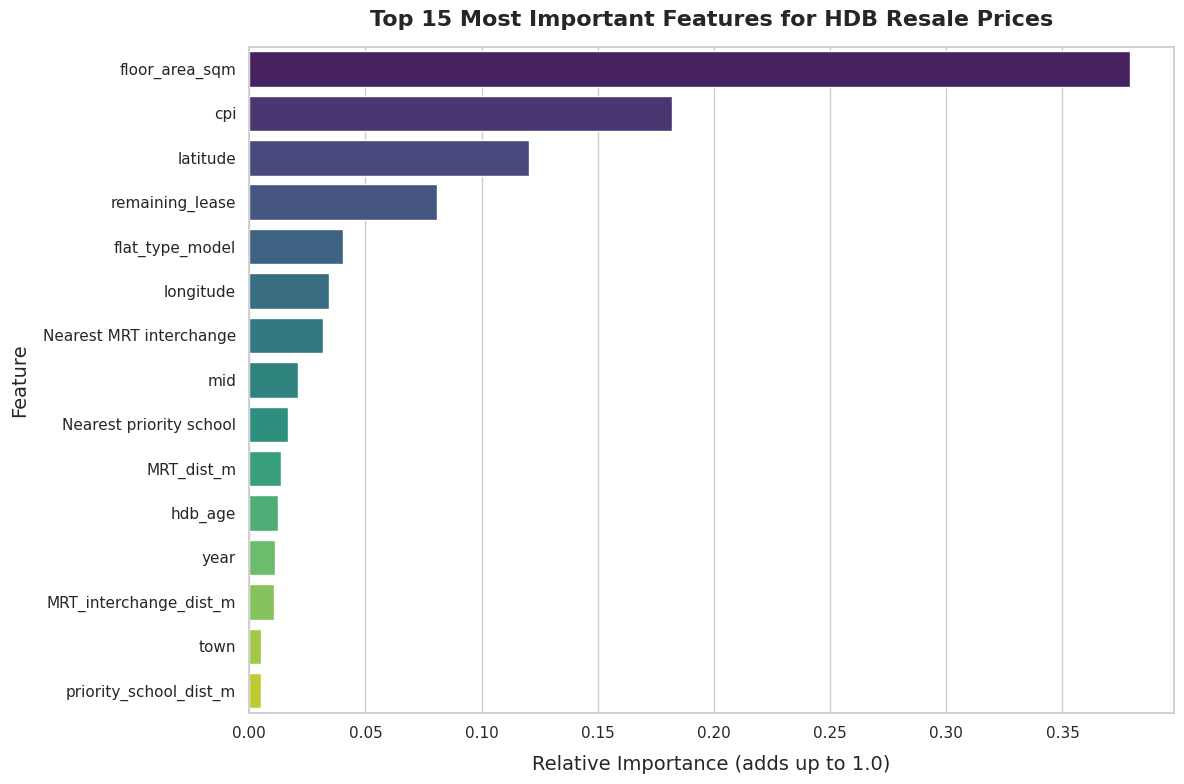

In [ ]:
# 1. Extract the importance scores and match them to your column names
importances = rf_model.feature_importances_
features = X_train_rf.columns

# 2. Create a DataFrame and sort it from most to least important
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Set up the visual canvas
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 4. Plot the Top 15 features
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

# 5. Format to look professional
plt.title('Top 15 Most Important Features for HDB Resale Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (adds up to 1.0)', fontsize=14, labelpad=10)
plt.ylabel('Feature', fontsize=14, labelpad=10)

plt.tight_layout()
plt.show()

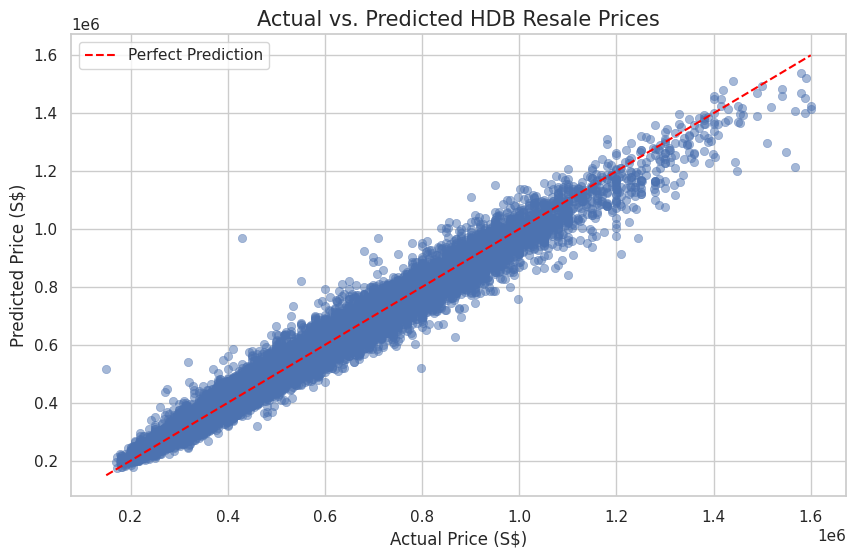

In [ ]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_test_preds, alpha=0.5, edgecolor=None)

# Add the 'Perfect Prediction' line
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted HDB Resale Prices', fontsize=15)
plt.xlabel('Actual Price (S$)', fontsize=12)
plt.ylabel('Predicted Price (S$)', fontsize=12)
plt.legend()
plt.show()

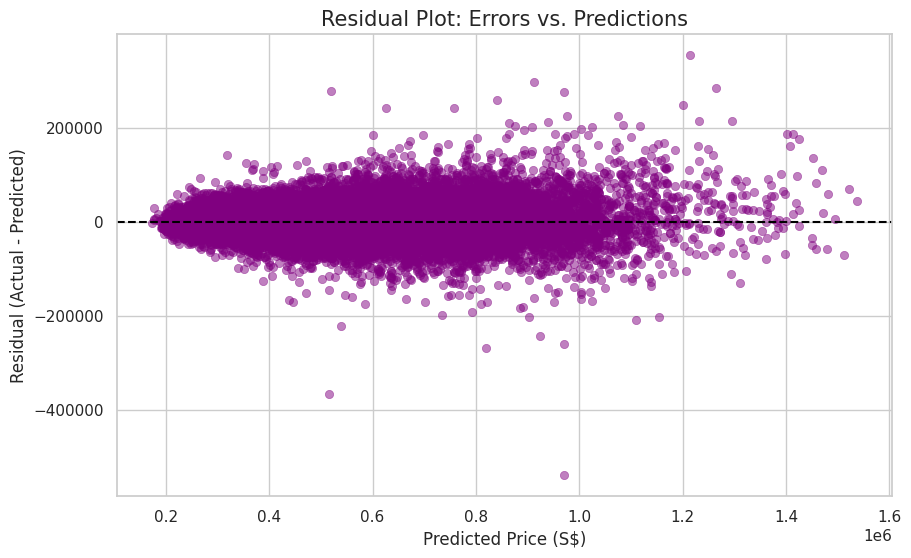

In [ ]:
# Calculate residuals
residuals = y_test - rf_test_preds

plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_test_preds, y=residuals, alpha=0.5, color='purple', edgecolor=None)

# Add a horizontal line at zero
plt.axhline(y=0, color='black', linestyle='--')

plt.title('Residual Plot: Errors vs. Predictions', fontsize=15)
plt.xlabel('Predicted Price (S$)', fontsize=12)
plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
plt.show()

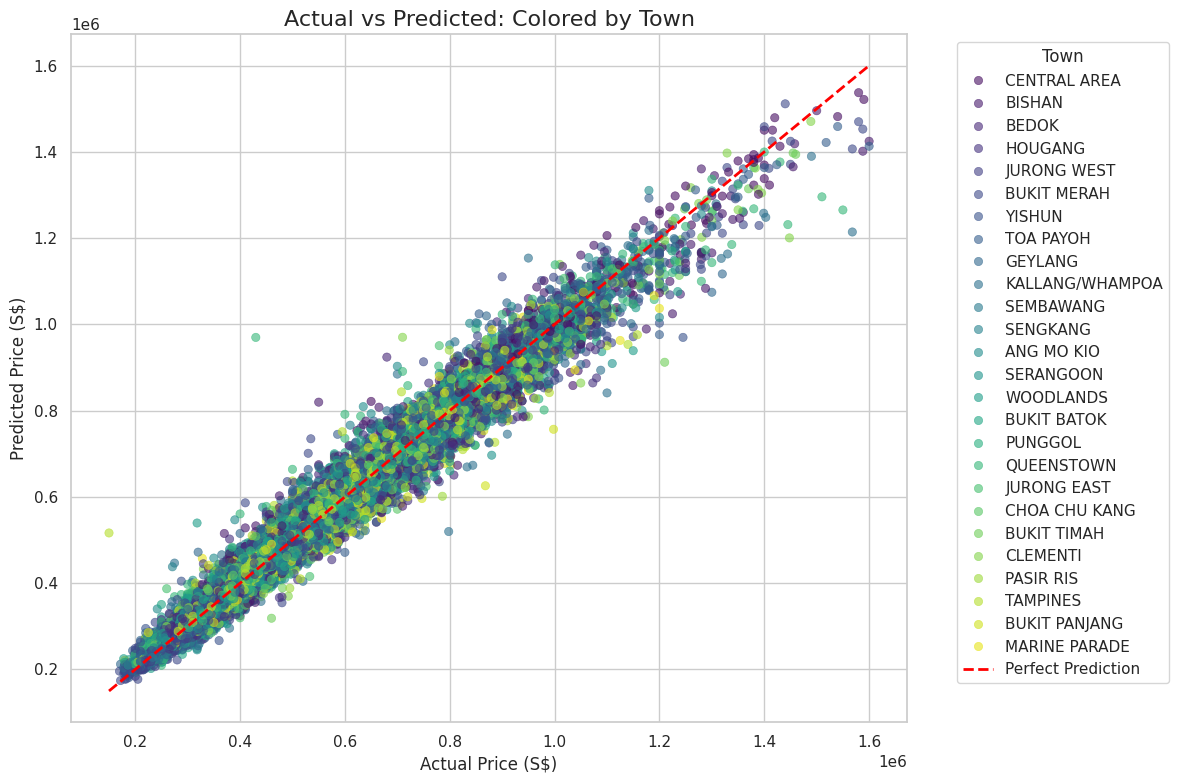

In [ ]:
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_test_preds,
    'Town': X_test['town'], # Ensure 'town' is in your X_test
    'Flat Type': X_test['flat_type_model'] # Changed from 'flat_type' to 'flat_type_model'
})

# 2. Create the Scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x='Actual',
    y='Predicted',
    hue='Town',        # Color by Town
    alpha=0.6,
    palette='viridis',
    edgecolor=None
)

# 3. Add the 'Perfect Prediction' line
line_coords = [plot_df['Actual'].min(), plot_df['Actual'].max()]
plt.plot(line_coords, line_coords, color='red', lw=2, linestyle='--', label='Perfect Prediction')

plt.title('Actual vs Predicted: Colored by Town', fontsize=16)
plt.xlabel('Actual Price (S$)', fontsize=12)
plt.ylabel('Predicted Price (S$)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Town') # Put legend outside
plt.tight_layout()
plt.show()

In [ ]:
# 1. Calculate the 'Error' (Residuals)
# Positive error means the actual price was higher than predicted (Under-prediction)
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_test_preds,
    'Error': y_test - rf_test_preds
})

# 2. Filter for "High Under-prediction" outliers (e.g., off by more than S$50,000)
high_errors = results[results['Error'] > 50000].sort_values(by='Error', ascending=False)

# 3. Merge back with your original features to see the characteristics of these flats
# Assuming X_test contains features like town, floor_area, etc.
error_analysis = high_errors.join(X_test)

print("Top 10 Flats where the model significantly under-predicted the price:")
print(error_analysis.head(10))

Top 10 Flats where the model significantly under-predicted the price:
           Actual     Predicted        Error  month  year             town  \
219981  1568000.0  1.214229e+06  353771.1200      7  2024  KALLANG/WHAMPOA   
186471  1210000.0  9.121817e+05  297818.2896      9  2023      BUKIT TIMAH   
223866  1550000.0  1.265283e+06  284717.4800     11  2024       QUEENSTOWN   
192975   798000.0  5.196900e+05  278310.0000      8  2023  KALLANG/WHAMPOA   
259223  1245000.0  9.697910e+05  275208.9600      7  2025           YISHUN   
193118  1100000.0  8.410589e+05  258941.1200     10  2023  KALLANG/WHAMPOA   
241481  1448000.0  1.200510e+06  247490.0000     11  2025         CLEMENTI   
239204   868000.0  6.258413e+05  242158.7200      9  2025    BUKIT PANJANG   
239540   998000.0  7.567581e+05  241241.9200      6  2025    BUKIT PANJANG   
242137  1300000.0  1.074448e+06  225552.4800      9  2025          GEYLANG   

       block     street_name  floor_area_sqm  remaining_lease  ...  \
2

Since my goal is to predict the actual price (a continuous numerical value) rather than a category (like "Expensive" vs. "Cheap").

In this case, we don't use a Confusion Matrix, Precision, or Recall. Instead, we use "Error Metrics" to see how far off my predictions are from the actual HDB resale prices.

For future buyers and sellers who need a reliable number, the most suitable metrics are Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R square Score.


In [ ]:
# 1. Grab the exact test rows from my ORIGINAL, UNENCODED dataset
# We use .loc[] to find the original rows that match the index of your test set

# Reload the initial raw CSV (hdb_final_with_cpi.csv) that was originally loaded into hdb_price.
# This is the rawest form of the data, retaining original indices from the CSV import.
raw_hdb_data = pd.read_csv('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_final_with_cpi.csv', low_memory=False)

# 2. Re-apply the EXACT cleaning steps used before the split
# This is vital so the row indices match X_test_rf.index perfectly

# a) Convert month & year integers to datetime
raw_hdb_data['sale_date'] = pd.to_datetime(raw_hdb_data['month'], format='%Y-%m')

# Create the 'year' column by extracting the year from the datetime object
raw_hdb_data['year'] = raw_hdb_data['sale_date'].dt.year
raw_hdb_data['month'] = raw_hdb_data['sale_date'].dt.month
raw_hdb_data['lease_commence_date'] = pd.to_datetime(raw_hdb_data['lease_commence_date'], format='%Y')

# Get a list of all current columns
cols = list(raw_hdb_data.columns)

# Remove 'year' from wherever it currently is (usually at the very end)
cols.remove('year')
cols.remove('sale_date')

# Find the position of 'month' and insert 'year' & 'sale_date' immediately after it
month_index = cols.index('month')
cols.insert(month_index + 1, 'year')
cols.insert(month_index + 2, 'sale_date')

# Reorder the DataFrame using the newly arranged column list
raw_hdb_data = raw_hdb_data[cols]


# b) Filter and convert NIL in 'postal code' to correct postal
sector_map = {
    "CHOA CHU KANG CTRL": "68"
}

mask = raw_hdb_data["postal_code"].astype(str).str.upper() == "NIL"

raw_hdb_data.loc[mask, "postal_code"] = (
    raw_hdb_data.loc[mask, "street_name"].map(sector_map) +
    raw_hdb_data.loc[mask, "block"].str.zfill(4)
)


# c) Compute Resale Price per sqm
raw_hdb_data['resale_price_per_sqm'] = round(((raw_hdb_data['resale_price']/ raw_hdb_data['floor_area_sqm']) ),2)


# d) get hdb age
raw_hdb_data['hdb_age'] = raw_hdb_data['year'] - raw_hdb_data['lease_commence_date'].dt.year


# e) Splits storey range to mid "04 TO 06" -> 5.0
temp_split = raw_hdb_data['storey_range'].str.split(' TO ', expand=True).astype(int)
raw_hdb_data['mid'] = (temp_split[0] + temp_split[1]) / 2

# f) Compute Resale Price Adjusted for Inflation Using Consumer Price Index for Housing & Utilities
raw_hdb_data['real_price'] = round(((raw_hdb_data['resale_price'] / raw_hdb_data['cpi']) * 100 ),2)
raw_hdb_data['real_price_per_sqm'] = round(((raw_hdb_data['real_price']/ raw_hdb_data['floor_area_sqm']) ),2)

# Drop only 100% identical rows & keep the rest
raw_hdb_data_final = raw_hdb_data.drop_duplicates()

raw_hdb_data_final.head()




,month,year,sale_date,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,...,num_mrt_1km,Nearest MRT interchange,MRT_interchange_dist_km,num_mrt_interchange_1km,cpi,resale_price_per_sqm,hdb_age,mid,real_price,real_price_per_sqm
0,1,2015,2015-01-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,07 TO 09,60.0,Improved,...,1.0,Bishan,3.013362,0.0,85.179,4250.00,29,8.0,299369.56,4989.49
1,1,2015,2015-01-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,1.0,Bishan,2.620788,0.0,85.179,4044.12,34,2.0,322849.53,4747.79
2,1,2015,2015-01-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,01 TO 03,69.0,New Generation,...,1.0,Bishan,2.831995,0.0,85.179,4130.43,35,2.0,334589.51,4849.12
3,1,2015,2015-01-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,...,1.0,Bishan,1.952634,0.0,85.179,4264.71,36,2.0,340459.50,5006.76
4,1,2015,2015-01-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,...,1.0,Bishan,2.445208,0.0,85.179,4264.71,35,8.0,340459.50,5006.76


In [ ]:
# 3. Grab the exact test rows using the index
# We use .copy() to avoid SettingWithCopy warnings
powerbi_df = raw_hdb_data_final.loc[X_test_rf.index].copy()

# 4. Attach predictions
# IMPORTANT: Use 'rf_test_preds' (the variable from RF model test step)
powerbi_df['Predicted_Price'] = rf_test_preds

# 5. Calculate Metrics for Power BI Visualization
powerbi_df['Price_Difference'] = powerbi_df['resale_price'] - powerbi_df['Predicted_Price']

# 6. Export to a clean CSV file
# index=False prevents pandas from writing the row numbers into the file
output_dir = Path('/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter')
output_dir.mkdir(parents=True, exist_ok=True)
file_name = output_dir / 'hdb_predictions_for_powerbi.csv'
powerbi_df.to_csv(file_name, index=False)

# print(f"Success! Your data has been exported to: {file_name}")
print(f"Shape of export: {powerbi_df.shape}")

# Take a quick peek at the last few columns to verify your predictions are there
display(powerbi_df.iloc[:, -5:].head())

Shape of export: (52004, 47)


,mid,real_price,real_price_per_sqm,Predicted_Price,Price_Difference
70367,5.0,507294.55,6186.52,448340.88,-13340.88
3961,5.0,846447.66,6995.44,716885.50,2002.50
76052,8.0,344602.01,5067.68,290895.00,4105.00
189442,5.0,867150.48,5523.25,865648.88,-25648.88
110372,11.0,544313.45,4425.31,467810.00,-3810.00


**To build an interactive predictive model map on Streamlit**


---



In [98]:
#Step 1: Export My Model and Encoders
# 1. Save the champion Random Forest model
joblib.dump(rf_model, '/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_rf_model.joblib', compress=('lzma', 3))

# 2. Save the Label Encoders (so Streamlit can translate "Bedok" back to '2')
joblib.dump(label_encoders, '/content/drive/MyDrive/GA Data analytics Capstone/CSV from Jupyter/hdb_label_encoders.joblib')

print("Success! Your model and encoders are saved and ready for Streamlit.")

Success! Your model and encoders are saved and ready for Streamlit.


In [ ]:
# Calculate the median for every column in my training set
feature_medians = X_train_rf.median()

# Print it out exactly how Streamlit needs it formatted
print("Copy and paste this into my app.py:\n")
print("input_data = {")

for column_name, median_value in feature_medians.items():
    # We round to 2 decimal places to keep the code looking clean
    print(f"    '{column_name}': {median_value:.2f},")

print("}")

Copy and paste this into my app.py:

input_data = {
    'month': 7.00,
    'year': 2021.00,
    'town': 14.00,
    'floor_area_sqm': 93.00,
    'remaining_lease': 73.83,
    'latitude': 1.37,
    'longitude': 103.85,
    'num_bus_stop_1km': 51.00,
    'num_hawker_1km': 1.00,
    'num_park_1km': 2.00,
    'num_mall_1km': 2.00,
    'Nearest school': 143.00,
    'num_school_1km': 5.00,
    'num_school_2km': 15.00,
    'Nearest priority school': 13.00,
    'num_priority_sch_1km': 0.00,
    'num_priority_sch_2km': 1.00,
    'Nearest MRT Station': 56.00,
    'num_mrt_1km': 1.00,
    'Nearest MRT interchange': 15.00,
    'num_mrt_interchange_1km': 0.00,
    'cpi': 86.88,
    'bus_stop_dist_m': 107.12,
    'hawker_dist_m': 614.39,
    'park_dist_m': 662.23,
    'mall_dist_m': 600.07,
    'MRT_interchange_dist_m': 2731.77,
    'priority_school_dist_m': 1643.47,
    'MRT_dist_m': 713.64,
    'school_dist_m': 287.59,
    'hdb_age': 25.00,
    'mid': 8.00,
    'flat_type_model': 18.00,
}
